# Wind CFD GNN -- Kaggle T4x2 | Vorticity-Aware Clustering
---
**Upgrades vs previous version:**
- Kaggle T4x2 paths, DataParallel, MAX_CELLS=50000, HIDDEN=128, LAYERS=10, EPOCHS=15000
- **CLUSTERING-1 (senior requirement):** case-level KMeans now includes:
  - Mean + 95th-pct vorticity |omega| per case (WLS curl of OpenFOAM U field)
  - Building orientation angle vs wind direction (PCA on wall cell XY positions)
- **Feat-23 (node feature):** per-cell |omega| normalised added to graph -> NODE_IN_DIM=24
- All 12 original bugs remain fixed

**Dataset:** 5-case pilot now, 39-case production (uncomment roots in CONFIG cell)
**Mixed timestep support:** 2000 or 4000 -- highest numeric dir auto-selected per case

In [1]:
import subprocess, sys
def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])
pip('torch_geometric')
pip('trimesh', 'scipy', 'scikit-learn', 'tqdm', 'matplotlib', 'numpy')
print('Dependencies ready')


Dependencies ready


In [2]:
import os, re, json, math, time, random, hashlib
from pathlib import Path
from typing import List, Dict, Optional, Tuple
from collections import defaultdict, Counter

import numpy as np
import trimesh
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch.utils.checkpoint import checkpoint as ckpt_fn
from scipy.spatial import cKDTree
from scipy.stats import kurtosis as _kurtosis
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = True  # T4: allow autotuning

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPU  = torch.cuda.device_count()
print(f'Device: {DEVICE}  |  GPUs: {N_GPU}')
for i in range(N_GPU):
    props = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}  VRAM: {props.total_memory/1e9:.1f} GB')
print(f'DataParallel: {"YES - dual T4" if N_GPU > 1 else "NO"}')


Device: cuda  |  GPUs: 2
  GPU 0: Tesla T4  VRAM: 15.6 GB
  GPU 1: Tesla T4  VRAM: 15.6 GB
DataParallel: YES - dual T4


In [3]:
# ============================================================
# KAGGLE T4x2 CONFIG
# ============================================================
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

KAGGLE_INPUT   = Path('/kaggle/input/datasets/kunal320/dataset/mohali_dataset')
KAGGLE_WORKING = Path('/kaggle/working')
CACHE_DIR      = KAGGLE_WORKING / 'processed_data'
OUTPUT_DIR     = KAGGLE_WORKING / 'checkpoints'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NORM_PATH = OUTPUT_DIR / 'norm.json'

# Dataset roots
DATASET_ROOTS = [
    KAGGLE_INPUT / 'mohali_spring',
    KAGGLE_INPUT / 'mohali_summer',
    KAGGLE_INPUT / 'mohali_winter',
    KAGGLE_INPUT / 'mohali_autumn',
    KAGGLE_INPUT / 'dublin_Spring',
    KAGGLE_INPUT / 'dublin_Summer',
    KAGGLE_INPUT / 'dublin_Winter',
    KAGGLE_INPUT / 'mombasa_Summer',
    KAGGLE_INPUT / 'mombasa_Winter',
]

# Physics
NU    = 1.5e-5
RHO   = 1.225
P_REF = 101325.0

CLIP_LOW_PCT  = 1.0;  CLIP_HIGH_PCT = 99.0
UZ_CLIP_LOW   = 2.0;  UZ_CLIP_HIGH  = 98.0
ABL_ALPHA     = 0.25; ABL_Z_REF     = 10.0
GRAD_WEIGHT_K = 3.0

CHANNEL_WEIGHTS = [1.5, 1.5, 1.5, 0.7]  # [p, Ux, Uy, Uz]

# Graph
K_NEIGHBORS = 8
MAX_CELLS   = 8000   # ✅ 10000→8000: 39 cases + backward pass ke liye safe

# Model — memory ke hisaab se tune kiya
HIDDEN_DIM  = 64     # ✅ 128→64: sabse bada memory saver
LATENT_DIM  = 64     # ✅ 128→64
N_MP_LAYERS = 6      # ✅ 10→6: backward pass mein 4x kam intermediate tensors
OUT_DIM     = 4

# Training
EPOCHS          = 15000
BATCH_SIZE      = 1    # ✅ 2→1: single GPU par 2 graphs ek saath = double memory
LR              = 3e-4
LR_DECAY        = 0.5
LR_PATIENCE     = 40
WEIGHT_DECAY    = 1e-5
GRAD_CLIP       = 1.0
EARLY_STOP_PAT  = 150

# Loss weights
PHYSICS_WEIGHT       = 0.25
NEUMANN_P_WEIGHT     = 0.12
CURL_WEIGHT          = 0.05
BC_LOSS_WEIGHT       = 0.20
NEAR_BLD_LOSS_WEIGHT = 0.15

VAL_FRAC  = 0.15
TEST_FRAC = 0.10

# Flow zones
WEAK_ZONE_FRAC    = 0.30
WAKE_SPEED_FRAC   = 0.60
WAKE_DOWNSTREAM_M = 0.0
BL_HEIGHT_M       = 2.0

# NODE_IN_DIM=24: original 23 features + 1 vorticity (feat 23)
NODE_IN_DIM = 24
EDGE_IN_DIM = 6

print(f'Config -- Kaggle T4x2 | EPOCHS={EPOCHS} | EARLY_STOP={EARLY_STOP_PAT}')
print(f'  MAX_CELLS={MAX_CELLS}  HIDDEN={HIDDEN_DIM}  LATENT={LATENT_DIM}  LAYERS={N_MP_LAYERS}')
print(f'  BATCH_SIZE={BATCH_SIZE}  NODE_IN_DIM={NODE_IN_DIM} (23 + 1 vorticity)')
print(f'  NORM_PATH: {NORM_PATH}')
print(f'\nDataset roots ({len(DATASET_ROOTS)}):')
for r in DATASET_ROOTS:
    print(f'  {"OK" if r.exists() else "MISSING"}  {r}')

Config -- Kaggle T4x2 | EPOCHS=15000 | EARLY_STOP=150
  MAX_CELLS=8000  HIDDEN=64  LATENT=64  LAYERS=6
  BATCH_SIZE=1  NODE_IN_DIM=24 (23 + 1 vorticity)
  NORM_PATH: /kaggle/working/checkpoints/norm.json

Dataset roots (9):
  OK  /kaggle/input/datasets/kunal320/dataset/mohali_dataset/mohali_spring
  OK  /kaggle/input/datasets/kunal320/dataset/mohali_dataset/mohali_summer
  OK  /kaggle/input/datasets/kunal320/dataset/mohali_dataset/mohali_winter
  OK  /kaggle/input/datasets/kunal320/dataset/mohali_dataset/mohali_autumn
  OK  /kaggle/input/datasets/kunal320/dataset/mohali_dataset/dublin_Spring
  OK  /kaggle/input/datasets/kunal320/dataset/mohali_dataset/dublin_Summer
  OK  /kaggle/input/datasets/kunal320/dataset/mohali_dataset/dublin_Winter
  OK  /kaggle/input/datasets/kunal320/dataset/mohali_dataset/mombasa_Summer
  OK  /kaggle/input/datasets/kunal320/dataset/mohali_dataset/mombasa_Winter


In [4]:
# All OpenFOAM parsers -- BUG-2/3/4 fixed

def _foam_body(text: str) -> Tuple[str, int]:
    # [BUG-2] Handle sep==-1: use full text if '// *' not found
    text = text.replace('\r', '')
    sep  = text.find('// *')
    after = text[sep:] if sep >= 0 else text
    m = re.search(r'(\d+)\s*\n\(', after)
    if not m:
        raise ValueError('Cannot find list count in foam file')
    count = int(m.group(1))
    base  = sep if sep >= 0 else 0
    start = base + m.end()
    end   = text.find('\n)\n', start)
    if end == -1:
        end = text.find('\n)', start)
    return text[start:end], count


def _count_cells_from_owner(owner_file: Path) -> int:
    # [BUG-3] regex with optional spaces: nCells\s*:\s*(\d+)
    text = owner_file.read_text(errors='ignore')
    m = re.search(r'nCells\s*:\s*(\d+)', text)
    if m:
        return int(m.group(1))
    body, _ = _foam_body(text)
    arr = np.fromstring(body, sep='\n', dtype=np.int32)
    return int(arr.max()) + 1


def parse_foam_scalar(filepath: Path) -> np.ndarray:
    text = filepath.read_text(errors='ignore').replace('\r', '')
    m = re.search(r'internalField\s+nonuniform\s+List<scalar>\s+(\d+)\s*\(', text)
    if m:
        n = int(m.group(1)); start = m.end()
        end = text.find('\n)\n', start)
        if end == -1: end = text.find('\n)', start)
        return np.fromstring(text[start:end], sep='\n', dtype=np.float32)[:n]
    # [BUG-4] optional leading sign for negative uniform values
    m2 = re.search(r'internalField\s+uniform\s+([-+]?[\d.eE+-]+)', text)
    if m2:
        owner_file = filepath.parent.parent / 'constant' / 'polyMesh' / 'owner'
        n = _count_cells_from_owner(owner_file)
        return np.full(n, float(m2.group(1)), dtype=np.float32)
    raise ValueError(f'Cannot parse scalar: {filepath}')


def parse_foam_vector(filepath: Path) -> np.ndarray:
    text = filepath.read_text(errors='ignore').replace('\r', '')
    m = re.search(r'internalField\s+nonuniform\s+List<vector>\s+(\d+)\s*\(', text)
    if m:
        n = int(m.group(1)); start = m.end()
        end = text.find('\n)\n', start)
        if end == -1: end = text.find('\n)', start)
        tuples = re.findall(r'\(([^)]+)\)', text[start:end])[:n]
        return np.array([list(map(float, t.split())) for t in tuples], dtype=np.float32)
    m2 = re.search(r'internalField\s+uniform\s+\(([^)]+)\)', text)
    if m2:
        vec = np.array(list(map(float, m2.group(1).split())), dtype=np.float32)
        owner_file = filepath.parent.parent / 'constant' / 'polyMesh' / 'owner'
        n = _count_cells_from_owner(owner_file)
        return np.tile(vec, (n, 1))
    raise ValueError(f'Cannot parse vector: {filepath}')


def parse_foam_labellist(filepath: Path, dtype=np.int32) -> np.ndarray:
    text = filepath.read_text(errors='ignore')
    body, count = _foam_body(text)
    return np.fromstring(body, sep='\n', dtype=dtype)[:count]


def parse_foam_points(filepath: Path) -> np.ndarray:
    text = filepath.read_text(errors='ignore').replace('\r', '')
    body, count = _foam_body(text)
    tuples = re.findall(r'\(([^)]+)\)', body)[:count]
    return np.array([list(map(float, t.split())) for t in tuples], dtype=np.float32)


def parse_boundary_patches(mesh_dir: Path) -> Dict[str, Dict]:
    text = (mesh_dir / 'boundary').read_text(errors='ignore')
    patches = {}
    for m in re.finditer(
        r'(\w+)\s*\{[^}]*?type\s+(\w+);[^}]*?nFaces\s+(\d+);[^}]*?startFace\s+(\d+);',
        text, re.DOTALL
    ):
        patches[m.group(1)] = {
            'type': m.group(2), 'nFaces': int(m.group(3)), 'startFace': int(m.group(4))
        }
    return patches


def compute_cell_centers(case_dir: Path) -> Tuple[np.ndarray, Dict]:
    mesh_dir = case_dir / 'constant' / 'polyMesh'
    points   = parse_foam_points(mesh_dir / 'points')
    faces_text = (mesh_dir / 'faces').read_text(errors='ignore').replace('\r', '')
    body_f, n_faces = _foam_body(faces_text)
    face_entries = re.findall(r'\d+\(([^)]+)\)', body_f)[:n_faces]
    face_centers = np.array(
        [points[list(map(int, e.split()))].mean(axis=0) for e in face_entries],
        dtype=np.float32
    )
    owner     = parse_foam_labellist(mesh_dir / 'owner')
    neighbour = parse_foam_labellist(mesh_dir / 'neighbour')
    n_internal = len(neighbour)
    n_cells    = _count_cells_from_owner(mesh_dir / 'owner')
    cell_sum   = np.zeros((n_cells, 3), dtype=np.float64)
    cell_cnt   = np.zeros(n_cells, dtype=np.int32)
    n_fc   = len(face_centers)
    safe_o = min(n_fc, len(owner))
    safe_n = min(n_internal, n_fc)
    np.add.at(cell_sum, owner[:safe_o],     face_centers[:safe_o])
    np.add.at(cell_cnt, owner[:safe_o],     1)
    np.add.at(cell_sum, neighbour[:safe_n], face_centers[:safe_n])
    np.add.at(cell_cnt, neighbour[:safe_n], 1)
    cell_centers = (cell_sum / np.maximum(cell_cnt[:, None], 1)).astype(np.float32)
    patches = parse_boundary_patches(mesh_dir)
    boundary_cells = {
        name: set(owner[p['startFace']:p['startFace']+p['nFaces']].tolist())
        for name, p in patches.items()
    }
    return cell_centers, boundary_cells


def _find_converged_timestep(case_dir: Path) -> Optional[Path]:
    candidates = [(int(d.name), d) for d in case_dir.iterdir()
                  if d.is_dir() and re.fullmatch(r'\d+', d.name) and int(d.name) > 0]
    return max(candidates, key=lambda x: x[0])[1] if candidates else None


def parse_inlet_velocity(case_dir: Path) -> np.ndarray:
    u0 = case_dir / '0' / 'U'
    if not u0.exists():
        print(f'  [WARN] 0/U not found in {case_dir} -- using [4,0,0]')
        return np.array([4.0, 0.0, 0.0], dtype=np.float32)
    text = u0.read_text(errors='ignore')
    m = re.search(r'Uinlet\s+\(([^)]+)\)', text)
    if m:
        return np.array(list(map(float, m.group(1).split())), dtype=np.float32)
    m2 = re.search(r'inlet.*?fixedValue.*?uniform\s+\(([^)]+)\)', text, re.DOTALL)
    if m2:
        return np.array(list(map(float, m2.group(1).split())), dtype=np.float32)
    print(f'  [WARN] Cannot parse Uinlet from {u0} -- using [4,0,0]')
    return np.array([4.0, 0.0, 0.0], dtype=np.float32)


def load_case(case_dir: Path) -> Optional[Dict]:
    try:
        ts_dir = _find_converged_timestep(case_dir)
        if ts_dir is None:
            print(f'  [SKIP] No timestep: {case_dir.name}'); return None
        if not (ts_dir/'p').exists() or not (ts_dir/'U').exists():
            print(f'  [SKIP] Missing p/U: {ts_dir}'); return None
        p_vals  = parse_foam_scalar(ts_dir / 'p')
        u_vals  = parse_foam_vector(ts_dir / 'U')
        u_inlet = parse_inlet_velocity(case_dir)
        cell_centers, bnd_cells = compute_cell_centers(case_dir)
        k_vals = None
        if (ts_dir / 'k').exists():
            try: k_vals = parse_foam_scalar(ts_dir / 'k')
            except Exception: pass
        n = min(len(p_vals), len(u_vals), len(cell_centers))
        k_aligned = k_vals[:n] if k_vals is not None and len(k_vals) >= n else None
        location = case_dir.parent.name
        print(f'  OK {location}/{case_dir.name}: {n:,} cells  '
              f'U={np.linalg.norm(u_inlet):.1f} m/s  t={ts_dir.name}')
        return {
            'case_name': case_dir.name,
            'location':  location,
            'case_dir':  case_dir,
            'timestep':  int(ts_dir.name),
            'cell_centers': cell_centers[:n],
            'p': p_vals[:n], 'U': u_vals[:n], 'k': k_aligned,
            'Uinlet': u_inlet, 'boundary_cells': bnd_cells,
        }
    except Exception as e:
        print(f'  [ERROR] {case_dir}: {e}'); return None

print('All parsers ready -- BUG-2/3/4 fixed')


All parsers ready -- BUG-2/3/4 fixed


In [5]:
# NEW: Vorticity + Building-Orientation helpers
# Senior requirement: cluster on vorticity, building orientation, inlet velocity/direction.

def compute_vorticity_mag_np(pts_r: np.ndarray, U_vals: np.ndarray,
                              k: int = 8, subsample: int = 5000) -> np.ndarray:
    """
    Per-cell vorticity magnitude |omega| = |curl U| via WLS gradients.
    Subsamples large meshes then NN-assigns for speed.

    WLS system per node i:
      W_i = sum_j w_ij * dp_ij x dp_ij  (3x3)
      R_i = sum_j w_ij * dp_ij x dU_ij  (3x3)
      G_U_i = W_i^{-1} R_i              G_U[n,a,c] = dU_c/dx_a

    Curl:
      omega_x = G_U[:,1,2] - G_U[:,2,1]  (dUz/dy - dUy/dz)
      omega_y = G_U[:,2,0] - G_U[:,0,2]  (dUx/dz - dUz/dx)
      omega_z = G_U[:,0,1] - G_U[:,1,0]  (dUy/dx - dUx/dy)
    """
    N = len(pts_r)
    if N > subsample:
        rng     = np.random.default_rng(SEED)
        sub_idx = rng.choice(N, subsample, replace=False)
        sub_pts = pts_r[sub_idx]
        sub_U   = U_vals[sub_idx]
    else:
        sub_pts = pts_r
        sub_U   = U_vals

    Ns   = len(sub_pts)
    tree = cKDTree(sub_pts)
    k_s  = min(k + 1, Ns)
    _, idx_s = tree.query(sub_pts, k=k_s)

    src  = np.repeat(np.arange(Ns), k_s - 1)
    dst  = idx_s[:, 1:].reshape(-1)
    dpos = sub_pts[dst] - sub_pts[src]
    dist2 = (dpos ** 2).sum(axis=1).clip(min=0.01)
    w    = 1.0 / dist2
    dU   = sub_U[dst] - sub_U[src]
    wdp  = w[:, None] * dpos

    wdp_dpos = wdp[:, :, None] * dpos[:, None, :]   # (E,3,3)
    wdp_dU   = wdp[:, :, None] * dU[:, None, :]     # (E,3,3)

    W = np.zeros((Ns, 3, 3), dtype=np.float64)
    R = np.zeros((Ns, 3, 3), dtype=np.float64)
    np.add.at(W, src, wdp_dpos.astype(np.float64))
    np.add.at(R, src, wdp_dU.astype(np.float64))
    W += 1e-4 * np.eye(3)[None]

    G_U  = np.linalg.solve(W, R)   # (Ns,3,3) G_U[n,a,c] = dU_c/dx_a
    wx   = G_U[:, 1, 2] - G_U[:, 2, 1]
    wy   = G_U[:, 2, 0] - G_U[:, 0, 2]
    wz   = G_U[:, 0, 1] - G_U[:, 1, 0]
    vort = np.sqrt(wx**2 + wy**2 + wz**2).astype(np.float32)

    if N > subsample:
        _, nn_idx = tree.query(pts_r)
        return vort[nn_idx]
    return vort


def compute_building_orientation_angle(pts_r: np.ndarray,
                                        boundary_cells: Dict) -> float:
    """
    PCA on XY positions of building wall cells.
    Returns angle [rad] of principal axis (longest footprint direction).
    Used to compute wind-building alignment: cos(inlet_ang - bld_axis).
    """
    bld_cells = []
    for pname, cells in boundary_cells.items():
        if 'building' in pname.lower():
            bld_cells.extend([c for c in cells if c < len(pts_r)])
    if len(bld_cells) < 3:
        return 0.0
    bld_xy = pts_r[np.array(bld_cells)][:, :2].astype(np.float64)
    bld_xy -= bld_xy.mean(axis=0)
    cov     = bld_xy.T @ bld_xy
    evals, evecs = np.linalg.eigh(cov)
    principal = evecs[:, evals.argmax()]
    return float(np.arctan2(principal[1], principal[0]))

print('compute_vorticity_mag_np  ready -- WLS curl, subsample=5000')
print('compute_building_orientation_angle ready -- PCA principal axis (XY)')


compute_vorticity_mag_np  ready -- WLS curl, subsample=5000
compute_building_orientation_angle ready -- PCA principal axis (XY)


In [6]:
def discover_cases(roots) -> List[Path]:
    """Find OpenFOAM cases. Skips processor dirs, requires 0/ dir."""
    if isinstance(roots, Path): roots = [roots]
    seen, unique = set(), []
    for root in roots:
        if not root.exists():
            print(f'  [SKIP] Root not found: {root}'); continue
        for of in sorted(root.rglob('constant/polyMesh/owner')):
            cd = of.parent.parent.parent
            if re.match(r'processor\d+$', cd.name): continue
            if not (cd / '0').is_dir(): continue
            if cd not in seen:
                seen.add(cd); unique.append(cd)
    print(f'Found {len(unique)} valid cases across {len(roots)} dataset roots')
    return unique


case_dirs = discover_cases(DATASET_ROOTS)
print('\nLoading cases...')
raw_cases: List[Dict] = []
for cd in tqdm(case_dirs):
    r = load_case(cd)
    if r is not None: raw_cases.append(r)

print(f'\nLoaded: {len(raw_cases)} / {len(case_dirs)} cases')
print('\nCase summary:')
for c in raw_cases:
    print(f"  [{c['timestep']}]  {c['location']}/{c['case_name']}  "
          f"n={len(c['p']):,}  U={np.linalg.norm(c['Uinlet']):.2f} m/s")


Found 40 valid cases across 9 dataset roots

Loading cases...


  2%|▎         | 1/40 [00:29<19:15, 29.63s/it]

  OK mohali_spring/building1: 417,280 cells  U=2.6 m/s  t=4000


  5%|▌         | 2/40 [00:55<17:20, 27.39s/it]

  OK mohali_spring/building2: 373,609 cells  U=2.6 m/s  t=4000


...

  OK mombasa_Winter/building3: 246,393 cells  U=5.8 m/s  t=4000


 98%|█████████▊| 39/40 [12:39<00:18, 18.39s/it]

  OK mombasa_Winter/building4: 204,531 cells  U=5.8 m/s  t=4000


100%|██████████| 40/40 [12:59<00:00, 19.49s/it]

  OK mombasa_Winter/building5: 306,217 cells  U=5.8 m/s  t=4000

Loaded: 38 / 40 cases

Case summary:
  [4000]  mohali_spring/building1  n=417,280  U=2.60 m/s
  [4000]  mohali_spring/building2  n=373,609  U=2.60 m/s
  [4000]  mohali_spring/building3  n=246,393  U=2.60 m/s
  [4000]  mohali_spring/building4  n=204,531  U=2.60 m/s
  [4000]  mohali_spring/building5  n=306,217  U=2.60 m/s
  [4000]  mohali_summer/building2  n=380,885  U=2.40 m/s
  [4000]  mohali_summer/building3  n=518,208  U=2.40 m/s
  [4000]  mohali_summer/building4  n=239,348  U=2.40 m/s
  [4000]  mohali_summer/building5  n=512,744  U=2.40 m/s
  [2000]  mohali_winter/building2  n=378,727  U=2.50 m/s
  [2000]  mohali_winter/building3  n=226,375  U=2.50 m/s
  [2000]  mohali_winter/building4  n=209,935  U=2.50 m/s
  [2000]  mohali_winter/building5  n=317,367  U=2.50 m/s
  [4000]  mohali_autumn/building1  n=417,280  U=2.10 m/s
  [4000]  mohali_autumn/building2  n=373,609  U=2.10 m/s
  [4000]  mohali_autumn/building3  n=246,39

In [7]:
# ============================================================
# CLUSTERING-1 (Senior requirement)
# KMeans on case-level features including VORTICITY + BUILDING ORIENTATION
#
# Why: plain geometry clustering misses wake diversity.
# Cases with same geometry but different building orientation relative to wind
# have very different wake patterns -> must separate in splits.
#
# 10-D feature vector per case:
#   [0-2]  x,y,z domain range          -- geometry size
#   [3]    inlet speed |Uinlet|         -- flow regime
#   [4-5]  cos/sin of inlet angle       -- wind direction
#   [6]    mean cell z                  -- domain height bias
#   [7]    mean |omega|                 -- overall wake intensity
#   [8]    95th-pct |omega|             -- peak vortex strength
#   [9]    cos(inlet_ang - bld_axis)    -- wind-building alignment
# ============================================================

print('Computing vorticity + orientation for CLUSTERING-1...')

def extract_case_features(cases: List[Dict]) -> np.ndarray:
    feats = []
    for c in tqdm(cases, desc='case feats'):
        pts  = c['cell_centers']
        U    = c['U']
        ui   = c['Uinlet']
        spd  = float(np.linalg.norm(ui))
        ang  = float(np.arctan2(ui[1], ui[0]))

        xr   = float(pts[:,0].max() - pts[:,0].min())
        yr   = float(pts[:,1].max() - pts[:,1].min())
        zr   = float(pts[:,2].max() - pts[:,2].min())
        mz   = float(pts[:,2].mean())

        vort = compute_vorticity_mag_np(pts, U, k=8, subsample=5000)
        c['vort'] = vort   # store for later normalization
        mv   = float(vort.mean())
        p95v = float(np.percentile(vort, 95))

        bld_ang  = compute_building_orientation_angle(pts, c['boundary_cells'])
        rel_ort  = float(np.cos(ang - bld_ang))   # 1=aligned, 0=perp, -1=opposite

        feats.append([xr, yr, zr, spd, np.cos(ang), np.sin(ang),
                      mz, mv, p95v, rel_ort])
    return np.array(feats, dtype=np.float32)


case_feats   = extract_case_features(raw_cases)
scaler_case  = StandardScaler()
case_feats_s = scaler_case.fit_transform(case_feats)

N_CASE_CLUSTERS = max(2, min(8, len(raw_cases) // 4))
km_cases        = KMeans(n_clusters=N_CASE_CLUSTERS, n_init=15, random_state=SEED)
case_cluster_labels = km_cases.fit_predict(case_feats_s)

print(f'\nKMeans: {N_CASE_CLUSTERS} clusters  |  {len(raw_cases)} cases')
print(f'{"#":<4} {"Location/Case":<38} {"Cl":<5} {"m/s":>6} {"MeanVort":>10} {"Align":>8} {"ts":>6}')
print('-' * 78)
for i, c in enumerate(raw_cases):
    spd  = float(np.linalg.norm(c['Uinlet']))
    name = f"{c['location']}/{c['case_name']}"
    print(f'  {i:<3} {name:<38} C{case_cluster_labels[i]:<4} {spd:>6.2f}'
          f' {case_feats[i,7]:>10.4f} {case_feats[i,9]:>8.3f} {c["timestep"]:>6}')

ctr = Counter(case_cluster_labels.tolist())
print(f'\nCluster sizes: { {f"C{k}": v for k,v in sorted(ctr.items())} }')

# 3-panel plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CLUSTERING-1: KMeans (geometry + vorticity + orientation)', fontsize=12)
colors = plt.cm.tab10(np.linspace(0, 1, N_CASE_CLUSTERS))
spds   = np.linalg.norm(np.vstack([c['Uinlet'] for c in raw_cases]), axis=1)
for cl in range(N_CASE_CLUSTERS):
    m = case_cluster_labels == cl
    axes[0].scatter(spds[m], case_feats[m,0], color=colors[cl],
                    label=f'C{cl} (n={int(m.sum())})', s=80, edgecolors='k', lw=0.5)
    axes[1].scatter(spds[m], case_feats[m,7], color=colors[cl],
                    label=f'C{cl}', s=80, edgecolors='k', lw=0.5)
    axes[2].scatter(case_feats[m,9], case_feats[m,7], color=colors[cl],
                    label=f'C{cl}', s=80, edgecolors='k', lw=0.5)

for ax, xl, yl, ttl in [
    (axes[0],'Inlet speed [m/s]','X-range [m]','Speed vs Domain'),
    (axes[1],'Inlet speed [m/s]','Mean |omega| [1/s]','Speed vs Vorticity'),
    (axes[2],'Wind-Building Alignment','Mean |omega| [1/s]','Orientation vs Vorticity'),
]:
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(ttl)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'case_clusters_vorticity.png', dpi=150, bbox_inches='tight')
print(f'Saved case_clusters_vorticity.png')


Computing vorticity + orientation for CLUSTERING-1...


case feats: 100%|██████████| 38/38 [00:11<00:00,  3.34it/s]



KMeans: 8 clusters  |  38 cases
#    Location/Case                          Cl       m/s   MeanVort    Align     ts
------------------------------------------------------------------------------
  0   mohali_spring/building1                C0      2.60     0.5339   -0.670   4000
  1   mohali_spring/building2                C6      2.60     0.4075    1.000   4000
  2   mohali_spring/building3                C3      2.60     0.1396   -0.317   4000
  3   mohali_spring/building4                C7      2.60     0.5075   -0.682   4000
  4   mohali_spring/building5                C0      2.60     0.5232    0.991   4000
  5   mohali_summer/building2                C6      2.40     0.3755    0.706   4000
  6   mohali_summer/building3                C3      2.40     0.1663   -0.960   4000
  7   mohali_summer/building4                C7      2.40     0.4808   -0.997   4000
  8   mohali_summer/building5                C0      2.40     0.8100   -0.684   4000
  9   mohali_winter/building2          

In [8]:
# Global normalization -- includes vorticity stats

# vort fields computed in CLUSTERING-1 cell; compute any missing ones
for c in raw_cases:
    if 'vort' not in c:
        c['vort'] = compute_vorticity_mag_np(c['cell_centers'], c['U'])

all_p_abs  = np.concatenate([c['p']            for c in raw_cases])
all_p_raw  = all_p_abs - P_REF
all_U      = np.vstack  ([c['U']            for c in raw_cases])
all_pts    = np.vstack  ([c['cell_centers'] for c in raw_cases])
all_inlets = np.vstack  ([c['Uinlet'][None] for c in raw_cases])
all_vort   = np.concatenate([c['vort']      for c in raw_cases])

p_lo,  p_hi  = np.percentile(all_p_raw,   [CLIP_LOW_PCT, 97.0])
ux_lo, ux_hi = np.percentile(all_U[:,0],  [CLIP_LOW_PCT, CLIP_HIGH_PCT])
uy_lo, uy_hi = np.percentile(all_U[:,1],  [CLIP_LOW_PCT, CLIP_HIGH_PCT])
uz_lo, uz_hi = np.percentile(all_U[:,2],  [UZ_CLIP_LOW,  UZ_CLIP_HIGH])
vt_lo, vt_hi = np.percentile(all_vort,    [CLIP_LOW_PCT, CLIP_HIGH_PCT])

k_cases = [c for c in raw_cases if c.get('k') is not None]
if k_cases:
    all_k    = np.concatenate([c['k'] for c in k_cases])
    k_lo, k_hi = np.percentile(all_k, [CLIP_LOW_PCT, CLIP_HIGH_PCT])
    all_k_c  = np.clip(all_k, k_lo, k_hi)
    k_mean, k_std = float(all_k_c.mean()), float(all_k_c.std()) + 1e-8
else:
    k_lo, k_hi, k_mean, k_std = 0., 1., 0., 1.

p_c  = np.clip(all_p_raw,  p_lo,  p_hi)
vt_c = np.clip(all_vort,   vt_lo, vt_hi)
Ui_spd = np.linalg.norm(all_inlets, axis=1)

NORM: Dict = {
    'p_mean':  float(p_c.mean()),    'p_std':  float(p_c.std())  + 1e-8,
    'p_clip_lo': float(p_lo),        'p_clip_hi': float(p_hi),
    'Ux_mean': float(np.clip(all_U[:,0],ux_lo,ux_hi).mean()),
    'Ux_std':  float(np.clip(all_U[:,0],ux_lo,ux_hi).std()) + 1e-8,
    'Uy_mean': float(np.clip(all_U[:,1],uy_lo,uy_hi).mean()),
    'Uy_std':  float(np.clip(all_U[:,1],uy_lo,uy_hi).std()) + 1e-8,
    'Uz_mean': float(np.clip(all_U[:,2],uz_lo,uz_hi).mean()),
    'Uz_std':  float(np.clip(all_U[:,2],uz_lo,uz_hi).std()) + 1e-8,
    'ux_clip_lo': float(ux_lo), 'ux_clip_hi': float(ux_hi),
    'uy_clip_lo': float(uy_lo), 'uy_clip_hi': float(uy_hi),
    'uz_clip_lo': float(uz_lo), 'uz_clip_hi': float(uz_hi),
    'k_mean': k_mean, 'k_std': k_std,
    'k_clip_lo': float(k_lo), 'k_clip_hi': float(k_hi),
    'x_mean': float(all_pts[:,0].mean()), 'x_std': float(all_pts[:,0].std())+1e-8,
    'y_mean': float(all_pts[:,1].mean()), 'y_std': float(all_pts[:,1].std())+1e-8,
    'z_mean': float(all_pts[:,2].mean()), 'z_std': float(all_pts[:,2].std())+1e-8,
    'Ui_mean':       all_inlets.mean(axis=0).tolist(),
    'Ui_std':        (all_inlets.std(axis=0) + 1e-8).tolist(),
    'Ui_speed_mean': float(Ui_spd.mean()),
    'Ui_speed_std':  float(Ui_spd.std()) + 1e-8,
    # NEW: vorticity norm stats
    'vort_mean':    float(vt_c.mean()),
    'vort_std':     float(vt_c.std()) + 1e-8,
    'vort_clip_lo': float(vt_lo),
    'vort_clip_hi': float(vt_hi),
}

# [BUG-1 FIX] Canonical NORM_PATH
with open(NORM_PATH, 'w') as f: json.dump(NORM, f, indent=2)
print(f'NORM saved -> {NORM_PATH}')
print(f'  p   mean={NORM["p_mean"]:.2f}  std={NORM["p_std"]:.2f}')
print(f'  Ux  mean={NORM["Ux_mean"]:.3f}  std={NORM["Ux_std"]:.3f}')
print(f'  vort mean={NORM["vort_mean"]:.4f}  std={NORM["vort_std"]:.4f}')

print('\nKurtosis after clipping:')
for name, arr in [('p_gauge',p_c),
                  ('Ux',np.clip(all_U[:,0],ux_lo,ux_hi)),
                  ('Uy',np.clip(all_U[:,1],uy_lo,uy_hi)),
                  ('Uz',np.clip(all_U[:,2],uz_lo,uz_hi)),
                  ('vort',vt_c)]:
    k_ = float(_kurtosis(arr))
    print(f'  {name:<12}  kurtosis={k_:>6.2f}  {"WARN heavy" if abs(k_)>5 else "OK"}')


NORM saved -> /kaggle/working/checkpoints/norm.json
  p   mean=-0.59  std=11.43
  Ux  mean=-0.399  std=1.827
  vort mean=0.5151  std=0.7015

Kurtosis after clipping:
  p_gauge       kurtosis=  1.42  OK
  Ux            kurtosis=  1.08  OK
  Uy            kurtosis=  0.97  OK
  Uz            kurtosis=  2.08  OK
  vort          kurtosis=  7.16  WARN heavy


In [9]:
#backup of top cell
# Global normalization -- includes vorticity stats
# vort fields computed in CLUSTERING-1 cell; compute any missing ones
for c in raw_cases:
    if 'vort' not in c:
        c['vort'] = compute_vorticity_mag_np(c['cell_centers'], c['U'])

all_p_abs  = np.concatenate([c['p']            for c in raw_cases])
all_p_raw  = all_p_abs - P_REF
all_U      = np.vstack  ([c['U']            for c in raw_cases])
all_pts    = np.vstack  ([c['cell_centers'] for c in raw_cases])
all_inlets = np.vstack  ([c['Uinlet'][None] for c in raw_cases])
all_vort   = np.concatenate([c['vort']      for c in raw_cases])

p_lo,  p_hi  = np.percentile(all_p_raw,   [CLIP_LOW_PCT, 97.0])
ux_lo, ux_hi = np.percentile(all_U[:,0],  [CLIP_LOW_PCT, CLIP_HIGH_PCT])
uy_lo, uy_hi = np.percentile(all_U[:,1],  [CLIP_LOW_PCT, CLIP_HIGH_PCT])
uz_lo, uz_hi = np.percentile(all_U[:,2],  [UZ_CLIP_LOW,  UZ_CLIP_HIGH])

# ✅ FIX: vorticity ke liye tight clipping — kurtosis 7+ ko 5 se neeche laane ke liye
vt_lo, vt_hi = np.percentile(all_vort, [2.0, 96.0])  # pehle 1/99 tha

k_cases = [c for c in raw_cases if c.get('k') is not None]
if k_cases:
    all_k      = np.concatenate([c['k'] for c in k_cases])
    k_lo, k_hi = np.percentile(all_k, [CLIP_LOW_PCT, CLIP_HIGH_PCT])
    all_k_c    = np.clip(all_k, k_lo, k_hi)
    k_mean, k_std = float(all_k_c.mean()), float(all_k_c.std()) + 1e-8
else:
    k_lo, k_hi, k_mean, k_std = 0., 1., 0., 1.

p_c  = np.clip(all_p_raw, p_lo, p_hi)
vt_c = np.clip(all_vort,  vt_lo, vt_hi)

# ✅ FIX: vorticity ko log-transform karo — heavy tail distributions ke liye best practice
# log1p(x) = log(1+x), x>=0 guaranteed kyunki vort = magnitude (always positive)
vt_c_log  = np.log1p(vt_c)
vort_mean = float(vt_c_log.mean())
vort_std  = float(vt_c_log.std()) + 1e-8

Ui_spd = np.linalg.norm(all_inlets, axis=1)

NORM: Dict = {
    'p_mean':  float(p_c.mean()),    'p_std':  float(p_c.std())  + 1e-8,
    'p_clip_lo': float(p_lo),        'p_clip_hi': float(p_hi),
    'Ux_mean': float(np.clip(all_U[:,0],ux_lo,ux_hi).mean()),
    'Ux_std':  float(np.clip(all_U[:,0],ux_lo,ux_hi).std()) + 1e-8,
    'Uy_mean': float(np.clip(all_U[:,1],uy_lo,uy_hi).mean()),
    'Uy_std':  float(np.clip(all_U[:,1],uy_lo,uy_hi).std()) + 1e-8,
    'Uz_mean': float(np.clip(all_U[:,2],uz_lo,uz_hi).mean()),
    'Uz_std':  float(np.clip(all_U[:,2],uz_lo,uz_hi).std()) + 1e-8,
    'ux_clip_lo': float(ux_lo), 'ux_clip_hi': float(ux_hi),
    'uy_clip_lo': float(uy_lo), 'uy_clip_hi': float(uy_hi),
    'uz_clip_lo': float(uz_lo), 'uz_clip_hi': float(uz_hi),
    'k_mean': k_mean, 'k_std': k_std,
    'k_clip_lo': float(k_lo), 'k_clip_hi': float(k_hi),
    'x_mean': float(all_pts[:,0].mean()), 'x_std': float(all_pts[:,0].std())+1e-8,
    'y_mean': float(all_pts[:,1].mean()), 'y_std': float(all_pts[:,1].std())+1e-8,
    'z_mean': float(all_pts[:,2].mean()), 'z_std': float(all_pts[:,2].std())+1e-8,
    'Ui_mean':       all_inlets.mean(axis=0).tolist(),
    'Ui_std':        (all_inlets.std(axis=0) + 1e-8).tolist(),
    'Ui_speed_mean': float(Ui_spd.mean()),
    'Ui_speed_std':  float(Ui_spd.std()) + 1e-8,
    # ✅ FIX: log-transformed vorticity stats
    'vort_mean':     vort_mean,
    'vort_std':      vort_std,
    'vort_clip_lo':  float(vt_lo),
    'vort_clip_hi':  float(vt_hi),
    'vort_log':      True,   # ✅ flag — inference mein log1p apply karna yaad rahe
}

# [BUG-1 FIX] Canonical NORM_PATH
with open(NORM_PATH, 'w') as f: json.dump(NORM, f, indent=2)
print(f'NORM saved -> {NORM_PATH}')
print(f'  p   mean={NORM["p_mean"]:.2f}  std={NORM["p_std"]:.2f}')
print(f'  Ux  mean={NORM["Ux_mean"]:.3f}  std={NORM["Ux_std"]:.3f}')
print(f'  vort mean={NORM["vort_mean"]:.4f}  std={NORM["vort_std"]:.4f}  (log-scale)')

print('\nKurtosis after clipping:')
for name, arr in [('p_gauge', p_c),
                  ('Ux', np.clip(all_U[:,0],ux_lo,ux_hi)),
                  ('Uy', np.clip(all_U[:,1],uy_lo,uy_hi)),
                  ('Uz', np.clip(all_U[:,2],uz_lo,uz_hi)),
                  ('vort_raw', vt_c),
                  ('vort_log', vt_c_log)]:   # ✅ dono dikhao comparison ke liye
    k_ = float(_kurtosis(arr))
    print(f'  {name:<12}  kurtosis={k_:>6.2f}  {"WARN heavy" if abs(k_)>5 else "OK"}')

NORM saved -> /kaggle/working/checkpoints/norm.json
  p   mean=-0.59  std=11.43
  Ux  mean=-0.399  std=1.827
  vort mean=0.3343  std=0.3219  (log-scale)

Kurtosis after clipping:
  p_gauge       kurtosis=  1.42  OK
  Ux            kurtosis=  1.08  OK
  Uy            kurtosis=  0.97  OK
  Uz            kurtosis=  2.08  OK
  vort_raw      kurtosis=  2.23  OK
  vort_log      kurtosis=  0.46  OK


In [10]:
Ui_mean_arr = np.array(NORM['Ui_mean'], dtype=np.float32)
Ui_std_arr  = np.array(NORM['Ui_std'],  dtype=np.float32)

for c in tqdm(raw_cases, desc='apply norm'):
    N   = len(c['p'])
    pts = c['cell_centers']

    c['pts_n'] = np.stack([
        (pts[:,0]-NORM['x_mean'])/NORM['x_std'],
        (pts[:,1]-NORM['y_mean'])/NORM['y_std'],
        (pts[:,2]-NORM['z_mean'])/NORM['z_std'],
    ], axis=1).astype(np.float32)

    p_g      = np.clip(c['p']-P_REF, NORM['p_clip_lo'], NORM['p_clip_hi'])
    c['p_n'] = ((p_g-NORM['p_mean'])/NORM['p_std']).astype(np.float32)

    Ux_c = np.clip(c['U'][:,0], NORM['ux_clip_lo'], NORM['ux_clip_hi'])
    Uy_c = np.clip(c['U'][:,1], NORM['uy_clip_lo'], NORM['uy_clip_hi'])
    Uz_c = np.clip(c['U'][:,2], NORM['uz_clip_lo'], NORM['uz_clip_hi'])
    c['U_n'] = np.stack([
        (Ux_c-NORM['Ux_mean'])/NORM['Ux_std'],
        (Uy_c-NORM['Uy_mean'])/NORM['Uy_std'],
        (Uz_c-NORM['Uz_mean'])/NORM['Uz_std'],
    ], axis=1).astype(np.float32)

    if c.get('k') is not None:
        k_c = np.clip(c['k'], NORM['k_clip_lo'], NORM['k_clip_hi'])
        c['k_n'] = ((k_c-NORM['k_mean'])/NORM['k_std']).astype(np.float32)
    else:
        c['k_n'] = np.zeros(N, dtype=np.float32)

    # vorticity normalization (NEW)
    vt_c = np.clip(c['vort'], NORM['vort_clip_lo'], NORM['vort_clip_hi'])
    c['vort_n'] = np.clip(
        (vt_c - NORM['vort_mean']) / NORM['vort_std'], -3.0, 3.0
    ).astype(np.float32)

    c['ui_n']       = ((c['Uinlet']-Ui_mean_arr)/Ui_std_arr).astype(np.float32)
    spd             = float(np.linalg.norm(c['Uinlet']))
    c['ui_speed_n'] = float((spd-NORM['Ui_speed_mean'])/NORM['Ui_speed_std'])
    if 'location' not in c: c['location'] = c.get('case_name','unknown')

all_p_n  = np.concatenate([c['p_n']      for c in raw_cases])
all_Ux_n = np.concatenate([c['U_n'][:,0] for c in raw_cases])
print(f'Norm sanity: p_n  mean={all_p_n.mean():.4f}  std={all_p_n.std():.4f}')
print(f'Norm sanity: Ux_n mean={all_Ux_n.mean():.4f}  std={all_Ux_n.std():.4f}')


apply norm: 100%|██████████| 38/38 [00:00<00:00, 61.39it/s]


Norm sanity: p_n  mean=-0.0000  std=1.0000
Norm sanity: Ux_n mean=-0.0000  std=1.0000


In [11]:
# Load owner-neighbour edge sets; store per-case for graph construction
print('Loading owner-neighbour edge sets...')
for c in tqdm(raw_cases, desc='foam edges'):
    case_dir = c.get('case_dir')
    if case_dir is None:
        c['foam_edge_set'] = set()
        print(f'  [WARN] case_dir missing for {c["location"]}/{c["case_name"]}')
        continue
    mesh_dir = case_dir / 'constant' / 'polyMesh'
    if not (mesh_dir/'owner').exists() or not (mesh_dir/'neighbour').exists():
        c['foam_edge_set'] = set(); continue
    try:
        owner_arr = parse_foam_labellist(mesh_dir / 'owner')
        nb_arr    = parse_foam_labellist(mesh_dir / 'neighbour')
        n_int     = len(nb_arr)
        src_all   = np.concatenate([owner_arr[:n_int], nb_arr])
        dst_all   = np.concatenate([nb_arr, owner_arr[:n_int]])
        c['foam_edge_set'] = set(zip(src_all.tolist(), dst_all.tolist()))
    except Exception as e:
        print(f'  [WARN] foam edges {c["location"]}/{c["case_name"]}: {e}')
        c['foam_edge_set'] = set()
print('Foam edge sets loaded.')


Loading owner-neighbour edge sets...


foam edges: 100%|██████████| 38/38 [00:47<00:00,  1.24s/it]

Foam edge sets loaded.


In [12]:
def _bnd_feat_flexible(bnd: Dict, keywords: List[str], N: int) -> np.ndarray:
    # [BUG-10] Case-insensitive partial patch name match
    arr = np.zeros((N, 1), dtype=np.float32)
    for kw in keywords:
        for pname, cells in bnd.items():
            if kw.lower() in pname.lower():
                valid = [c for c in cells if c < N]
                if valid: arr[valid, 0] = 1.0
    return arr


def build_graph(case: Dict, k: int = K_NEIGHBORS,
                max_cells: Optional[int] = MAX_CELLS) -> Data:
    """
    Build k-NN graph. NODE_IN_DIM=24, EDGE_IN_DIM=6.

    Feature map (indices 10-13 FIXED for physics/BC loss):
      0-2:  pts_n              normalised xyz
      3-5:  ui_broadcast       inlet velocity broadcast to all nodes
      6:    inlet_speed        |Uinlet| normalised
      7:    z_norm             height/z_max
      8:    upstream_dist_bld  signed dist along wind from building centroid
      9:    ground_flag        sigmoid proximity to ground
      10:   is_building        1 if building wall   <- physics/BC anchor
      11:   is_ground          1 if ground wall     <- physics/BC anchor
      12:   is_inlet           1 if inlet patch     <- physics/BC anchor
      13:   is_outlet          1 if outlet patch    <- physics/BC anchor
      14:   dist_to_bld        normalised dist to nearest building cell
      15:   wind_align         pts_n . ui_unit (streamline position)
      16:   inlet_cos          cos(wind angle)
      17:   inlet_sin          sin(wind angle)
      18:   abl_ratio          (z/z_ref)^0.25
      19:   k_norm             turbulent kinetic energy normalised
      20:   spatial_cluster    spatial KMeans zone id (CLUSTERING-2)
      21:   wake_flag          soft downstream cone indicator
      22:   lateral_to_bld_n   perp dist from wind axis through bld centroid
      23:   vort_n             |omega| normalised  <- NEW (senior requirement)
    """
    pts_n  = case['pts_n']
    pts_r  = case['cell_centers']
    p_n    = case['p_n']
    U_n    = case['U_n']
    k_n    = case['k_n']
    vort_n = case['vort_n']   # NEW
    ui_n   = case['ui_n']
    bnd    = case['boundary_cells']
    N_orig = len(p_n)

    # Boundary-preserving subsampling
    if max_cells is not None and N_orig > max_cells:
        bnd_indices = set()
        for patch_cells in bnd.values():
            for ci in patch_cells:
                if ci < N_orig: bnd_indices.add(ci)
        bnd_arr  = np.array(sorted(bnd_indices), dtype=np.int64)
        interior = np.array([i for i in range(N_orig) if i not in bnd_indices], dtype=np.int64)
        n_fill   = max(0, max_cells - len(bnd_arr))
        rng = np.random.default_rng(SEED ^ (hash(case['case_name']) & 0xFFFF))
        interior_chosen = rng.choice(interior, min(n_fill, len(interior)), replace=False)
        idx = np.sort(np.concatenate([bnd_arr, interior_chosen])).astype(np.int64)
    else:
        idx = np.arange(N_orig, dtype=np.int64)

    pts_n  = pts_n[idx];  pts_r  = pts_r[idx]
    p_n    = p_n[idx];    U_n    = U_n[idx]
    k_n    = k_n[idx];    vort_n = vort_n[idx]
    idx_set = set(idx.tolist())
    idx_inv = {old: new for new, old in enumerate(idx.tolist())}
    bnd = {name: {idx_inv[c] for c in cells if c in idx_set}
           for name, cells in bnd.items()}
    N = len(p_n)

    # Boundary flags (indices 10-13 -- must not change)
    is_building = _bnd_feat_flexible(bnd, ['building'], N)
    is_ground   = _bnd_feat_flexible(bnd, ['ground'],   N)
    is_inlet    = _bnd_feat_flexible(bnd, ['inlet'],    N)
    is_outlet   = _bnd_feat_flexible(bnd, ['outlet'],   N)

    # Basic geometric features
    ui_broadcast  = np.tile(ui_n, (N, 1))
    inlet_speed_n = float(
        (np.linalg.norm(case['Uinlet']) - NORM['Ui_speed_mean']) / NORM['Ui_speed_std']
    )
    inlet_speed   = np.full((N, 1), inlet_speed_n, dtype=np.float32)
    z_max         = float(pts_r[:, 2].max()) + 1e-6
    z_norm        = np.clip(pts_r[:, 2:3] / z_max, 0.0, 1.0).astype(np.float32)
    ground_flag   = (1.0 / (1.0 + np.exp(20.0 * np.clip(z_norm, 0, 1)))).astype(np.float32)
    angle_rad     = float(np.arctan2(case['Uinlet'][1], case['Uinlet'][0]))
    inlet_cos     = np.full((N, 1), np.cos(angle_rad), dtype=np.float32)
    inlet_sin     = np.full((N, 1), np.sin(angle_rad), dtype=np.float32)
    z_raw         = pts_r[:, 2:3].clip(min=0.01)
    abl_ratio     = np.clip((z_raw / ABL_Z_REF) ** ABL_ALPHA, 0.0, 3.0).astype(np.float32)
    k_feat        = k_n.reshape(-1, 1)

    # dist_to_bld
    bld_set = set()
    for pname, cells in bnd.items():
        if 'building' in pname.lower(): bld_set |= cells
    if bld_set:
        bld_cells_arr = np.array([c for c in bld_set if c < N])
        if len(bld_cells_arr) > 0:
            bld_pts = pts_r[bld_cells_arr]
            _, d2bld = cKDTree(bld_pts).query(pts_r)
            dist_to_bld = (d2bld / (float(d2bld.max()) + 1e-6)).reshape(-1, 1).astype(np.float32)
        else:
            bld_pts     = pts_r.mean(axis=0, keepdims=True)
            dist_to_bld = np.ones((N, 1), dtype=np.float32)
    else:
        bld_pts     = pts_r.mean(axis=0, keepdims=True)
        dist_to_bld = np.ones((N, 1), dtype=np.float32)

    bld_cells_arr_safe = bld_cells_arr if (bld_set and len(bld_cells_arr)>0) else np.arange(min(10,N))

    # FEAT 8: upstream_dist_bld (signed wind-aligned dist from building)
    wind_dir_unit = case['Uinlet'] / (np.linalg.norm(case['Uinlet']) + 1e-8)
    bld_cen_r     = bld_pts.mean(axis=0) if len(bld_pts.shape)==2 else bld_pts
    along_bld     = (pts_r - bld_cen_r) @ wind_dir_unit
    domain_scale  = float(pts_r[:, 0].max() - pts_r[:, 0].min()) + 1e-6
    upstream_dist_bld_n = np.clip(
        along_bld / domain_scale, -1.0, 1.0
    ).reshape(-1, 1).astype(np.float32)

    # FEAT 15: wind_align
    ui_unit_n  = ui_n / (np.linalg.norm(ui_n) + 1e-8)
    wind_align = (pts_n @ ui_unit_n).reshape(-1, 1).astype(np.float32)

    # FEAT 20: spatial KMeans (CLUSTERING-2)
    N_SPATIAL    = max(4, min(16, N // 500))
    km_sp        = KMeans(n_clusters=N_SPATIAL, n_init=3, max_iter=50, random_state=SEED)
    sp_id        = km_sp.fit_predict(pts_n).astype(np.float32)
    spatial_feat = (sp_id / max(N_SPATIAL - 1, 1)).reshape(-1, 1)

    # FEAT 21: wake_flag (soft downstream cone)
    bld_h      = float(pts_r[bld_cells_arr_safe, 2].max())
    wake_sigma = max(bld_h * 2.0, 5.0)
    wind_horiz = wind_dir_unit.copy(); wind_horiz[2] = 0.0
    wind_perp_h = np.array([-wind_horiz[1], wind_horiz[0], 0.0], dtype=np.float32)
    lateral_vec = (pts_r - bld_cen_r) @ wind_perp_h
    downstream_s = 1.0 / (1.0 + np.exp(-along_bld / (wake_sigma * 0.5)))
    lateral_s    = np.exp(-(lateral_vec ** 2) / (wake_sigma ** 2))
    wake_flag    = (downstream_s * lateral_s).reshape(-1, 1).astype(np.float32)

    # FEAT 22: lateral_to_bld_n
    lateral_to_bld_n = (
        np.abs(lateral_vec) / (domain_scale + 1e-6)
    ).reshape(-1, 1).clip(0, 1).astype(np.float32)

    # FEAT 23: vorticity magnitude (NEW)
    vort_feat = vort_n.reshape(-1, 1)

    # Concatenate all 24 node features
    node_feats = np.concatenate([
        pts_n,               # 0-2
        ui_broadcast,        # 3-5
        inlet_speed,         # 6
        z_norm,              # 7
        upstream_dist_bld_n, # 8
        ground_flag,         # 9
        is_building,         # 10  <- physics anchor
        is_ground,           # 11  <- physics anchor
        is_inlet,            # 12  <- physics anchor
        is_outlet,           # 13  <- physics anchor
        dist_to_bld,         # 14
        wind_align,          # 15
        inlet_cos,           # 16
        inlet_sin,           # 17
        abl_ratio,           # 18
        k_feat,              # 19
        spatial_feat,        # 20
        wake_flag,           # 21
        lateral_to_bld_n,    # 22
        vort_feat,           # 23  <- vorticity (NEW)
    ], axis=1).astype(np.float32)   # (N, 24)

    # k-NN edges
    tree = cKDTree(pts_n)
    _, indices = tree.query(pts_n, k=k + 1)
    sources = np.repeat(np.arange(N), k)
    targets = indices[:, 1:].reshape(-1)

    # [BUG-5] Remap foam global->local indices
    foam_edges_global: set = case.get('foam_edge_set', set())
    if foam_edges_global and idx_inv:
        foam_edges_local = {(idx_inv[g], idx_inv[d])
                            for (g, d) in foam_edges_global
                            if g in idx_inv and d in idx_inv}
    else:
        foam_edges_local = set()

    if foam_edges_local:
        src_l = sources.tolist(); dst_l = targets.tolist()
        edge_foam = np.array(
            [(1.0 if (src_l[i], dst_l[i]) in foam_edges_local else 0.0)
             for i in range(len(sources))],
            dtype=np.float32
        ).reshape(-1, 1)
    else:
        edge_foam = np.zeros((len(sources), 1), dtype=np.float32)

    rel_disp    = pts_n[targets] - pts_n[sources]
    rel_dist    = np.linalg.norm(rel_disp, axis=1, keepdims=True)
    ui_unit_raw = case['Uinlet'] / (np.linalg.norm(case['Uinlet']) + 1e-8)
    wind_proj   = (pts_r[targets] - pts_r[sources]) @ ui_unit_raw
    wind_proj_n = (wind_proj / (rel_dist.squeeze() + 1e-4)).reshape(-1, 1)
    edge_feats  = np.concatenate(
        [rel_disp, rel_dist, edge_foam, wind_proj_n], axis=1
    ).astype(np.float32)   # (E, 6)

    y = np.concatenate([p_n[:, None], U_n], axis=1).astype(np.float32)

    return Data(
        x          = torch.tensor(node_feats,                   dtype=torch.float32),
        edge_index = torch.tensor(np.stack([sources, targets]),  dtype=torch.long),
        edge_attr  = torch.tensor(edge_feats,                    dtype=torch.float32),
        y          = torch.tensor(y,                             dtype=torch.float32),
        pos        = torch.tensor(pts_r,                         dtype=torch.float32),
        Uinlet_raw = torch.tensor(case['Uinlet'],                dtype=torch.float32),
        case_name  = case['case_name'],
        location   = case['location'],
    )

print('build_graph ready -- NODE_IN_DIM=24')
print('  feat 23 = |omega| (vorticity magnitude, normalised)')
print('  Indices 10-13 (is_bld/gnd/inlet/outlet) unchanged -- physics loss safe')


build_graph ready -- NODE_IN_DIM=24
  feat 23 = |omega| (vorticity magnitude, normalised)
  Indices 10-13 (is_bld/gnd/inlet/outlet) unchanged -- physics loss safe


In [13]:
norm_hash  = hashlib.md5(json.dumps(NORM, sort_keys=True).encode()).hexdigest()[:8]
CACHE_FILE = CACHE_DIR / f'graphs_k{K_NEIGHBORS}_max{MAX_CELLS}_{norm_hash}.pt'

if CACHE_FILE.exists():
    print(f'Loading cached graphs: {CACHE_FILE}')
    graph_list: List[Data] = torch.load(CACHE_FILE)
else:
    print('Building graphs (this may take a few minutes on large meshes)...')
    graph_list = [build_graph(c) for c in tqdm(raw_cases, desc='build graphs')]
    torch.save(graph_list, CACHE_FILE)
    print(f'Cached -> {CACHE_FILE}')

g0 = graph_list[0]
print(f'Total: {len(graph_list)}  nodes={g0.num_nodes}  edges={g0.num_edges}  '
      f'x={g0.x.shape[1]}  ea={g0.edge_attr.shape[1]}')
NODE_IN_DIM = g0.x.shape[1]
EDGE_IN_DIM = g0.edge_attr.shape[1]
print(f'NODE_IN_DIM={NODE_IN_DIM}  EDGE_IN_DIM={EDGE_IN_DIM}  (auto-detected)')
assert NODE_IN_DIM == 24, f'Expected 24 node features, got {NODE_IN_DIM}'


Building graphs (this may take a few minutes on large meshes)...


build graphs: 100%|██████████| 38/38 [01:26<00:00,  2.28s/it]


Cached -> /kaggle/working/processed_data/graphs_k8_max8000_e7fe08ce.pt
Total: 38  nodes=160075  edges=1280600  x=24  ea=6
NODE_IN_DIM=24  EDGE_IN_DIM=6  (auto-detected)


In [14]:
# ✅ FIX: Ensure all graphs are on CPU before DataLoader (avoids CUDA collation crash)
graph_list = [g.cpu() for g in graph_list]

# Cluster-aware train/val/test split -- BUG-7 fixed
rng_split = np.random.default_rng(SEED)

if len(graph_list) <= 6:
    print(f'  {len(graph_list)} samples -> N-1 train / 1 val / 0 test')
    all_idx   = np.arange(len(graph_list)); rng_split.shuffle(all_idx)
    val_idx   = [int(all_idx[0])]
    train_idx = all_idx[1:].tolist()
    test_idx  = []
else:
    cluster_to_idx: Dict[int, List[int]] = defaultdict(list)
    for i, lbl in enumerate(case_cluster_labels):
        cluster_to_idx[int(lbl)].append(i)
    train_idx, val_idx, test_idx = [], [], []
    for cl, idxs in sorted(cluster_to_idx.items()):
        arr = np.array(idxs); rng_split.shuffle(arr); n = len(arr)
        n_te = max(1, round(n * TEST_FRAC)) if n >= 3 else 0
        n_va = max(1, round(n * VAL_FRAC))  if n >= 2 else 0
        n_tr = n - n_te - n_va
        if n_tr < 1:
            n_tr = 1; n_va = max(0, n - 1); n_te = 0
        test_idx  += arr[:n_te].tolist()
        val_idx   += arr[n_te: n_te + n_va].tolist()
        train_idx += arr[n_te + n_va:].tolist()
    test_set  = set(test_idx)
    val_set   = set(val_idx)  - test_set
    train_set = set(train_idx) - test_set - val_set
    train_idx = sorted(train_set); val_idx = sorted(val_set); test_idx = sorted(test_set)

train_graphs = [graph_list[i] for i in train_idx]
val_graphs   = [graph_list[i] for i in val_idx]
test_graphs  = [graph_list[i] for i in test_idx]

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)  # num_workers=0: avoids CUDA tensor in worker crash
val_loader   = DataLoader(val_graphs,   batch_size=1, shuffle=False)
test_loader  = DataLoader(test_graphs,  batch_size=1, shuffle=False)
n_train, n_val, n_test = len(train_graphs), len(val_graphs), len(test_graphs)

print(f'Cluster-aware split (vorticity+orientation): train={n_train}  val={n_val}  test={n_test}')
for split, idxs in [('TRAIN', train_idx), ('VAL', val_idx), ('TEST', test_idx)]:
    for i in idxs:
        g  = graph_list[i]
        cl = case_cluster_labels[i] if i < len(case_cluster_labels) else '?'
        print(f'  {split:<6} C{cl}  {g.location}/{g.case_name}')


Cluster-aware split (vorticity+orientation): train=22  val=8  test=8
  TRAIN  C0  mohali_spring/building1
  TRAIN  C3  mohali_spring/building3
  TRAIN  C0  mohali_spring/building5
  TRAIN  C6  mohali_summer/building2
  TRAIN  C3  mohali_summer/building3
  TRAIN  C6  mohali_winter/building2
  TRAIN  C7  mohali_winter/building4
  TRAIN  C0  mohali_autumn/building1
  TRAIN  C3  mohali_autumn/building3
  TRAIN  C7  mohali_autumn/building4
  TRAIN  C0  mohali_autumn/building5
  TRAIN  C1  dublin_Spring/building4
  TRAIN  C1  dublin_Summer/building2
  TRAIN  C5  dublin_Summer/building3
  TRAIN  C2  dublin_Summer/building4
  TRAIN  C2  dublin_Winter/building4
  TRAIN  C4  dublin_Winter/building5
  TRAIN  C6  mombasa_Summer/building2
  TRAIN  C7  mombasa_Summer/building4
  TRAIN  C0  mombasa_Summer/building5
  TRAIN  C5  mombasa_Winter/building3
  TRAIN  C4  mombasa_Winter/building5
  VAL    C7  mohali_spring/building4
  VAL    C0  mohali_summer/building5
  VAL    C6  mohali_autumn/building2
 

In [15]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, n_layers=2, activate_last=True):
        super().__init__()
        dims   = [in_dim] + [hidden] * (n_layers - 1) + [out_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2 or activate_last: layers.append(nn.SiLU())
        self.net  = nn.Sequential(*layers)
        self.norm = nn.LayerNorm(out_dim)
    def forward(self, x): return self.norm(self.net(x))

class MGNLayer(MessagePassing):
    def __init__(self, node_dim, edge_dim, hidden):
        super().__init__(aggr='mean')
        self.edge_mlp = MLP(node_dim*2 + edge_dim, hidden, edge_dim)
        self.node_mlp = MLP(node_dim   + edge_dim, hidden, node_dim)
    def forward(self, x, edge_index, edge_attr):
        row, col = edge_index
        new_edge = self.edge_mlp(torch.cat([x[row], x[col], edge_attr], dim=-1))
        new_x    = self.propagate(edge_index, x=x, edge_attr=new_edge)
        return new_x, new_edge
    def message(self, edge_attr): return edge_attr
    def update(self, aggr_out, x):
        return x + self.node_mlp(torch.cat([x, aggr_out], dim=-1))

class WindGNN(nn.Module):
    """MeshGraphNet -- separate p/U decoders, gradient checkpointing during training."""
    def __init__(self, node_in_dim=NODE_IN_DIM, edge_in_dim=EDGE_IN_DIM,
                 hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM,
                 n_mp_layers=N_MP_LAYERS, use_checkpointing=True):
        super().__init__()
        self.use_ckpt  = use_checkpointing
        self.node_enc  = MLP(node_in_dim, hidden_dim, latent_dim)
        self.edge_enc  = MLP(edge_in_dim, hidden_dim, latent_dim)
        self.mp_layers = nn.ModuleList([
            MGNLayer(latent_dim, latent_dim, hidden_dim) for _ in range(n_mp_layers)
        ])
        def _dec(out_ch):
            return nn.Sequential(
                nn.Linear(latent_dim, hidden_dim), nn.SiLU(), nn.Dropout(0.05),
                nn.Linear(hidden_dim, hidden_dim // 2), nn.SiLU(),
                nn.Linear(hidden_dim // 2, out_ch),
            )
        self.decoder_p = _dec(1)
        self.decoder_U = _dec(3)

    def forward(self, data: Data) -> torch.Tensor:
        x  = self.node_enc(data.x)
        ea = self.edge_enc(data.edge_attr)
        for mp in self.mp_layers:
            if self.use_ckpt and self.training:
                x, ea = ckpt_fn(mp, x, data.edge_index, ea, use_reentrant=False)
            else:
                x, ea = mp(x, data.edge_index, ea)
        return torch.cat([self.decoder_p(x), self.decoder_U(x)], dim=1)

# ── Model setup — Single GPU only (DataParallel PyG ke saath kaam nahi karta) ──
DEVICE = torch.device('cuda:0')  # sirf GPU 0 use karo
model  = WindGNN().to(DEVICE)

def _get_model():
    return model

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'WindGNN: node_in={NODE_IN_DIM}  edge_in={EDGE_IN_DIM}  '
      f'hidden={HIDDEN_DIM}  layers={N_MP_LAYERS}  params={n_params:,}')

# Sanity forward pass
# Sanity forward pass — graph_list ko corrupt mat karo
with torch.no_grad():
    import copy
    _s = copy.deepcopy(graph_list[0]).to(DEVICE)  # ✅ deepcopy — original CPU par rahega
    model.eval()
    _o = model(_s)
    model.train()
    print(f'Forward OK: {tuple(_o.shape)}  expected [{_s.num_nodes}, 4]')
    del _o, _s
    torch.cuda.empty_cache()

WindGNN: node_in=24  edge_in=6  hidden=64  layers=6  params=198,340
Forward OK: (160075, 4)  expected [160075, 4]


In [16]:
def _wls_jacobian(field, src, dst, dpos, dist, N):
    """WLS spatial gradient per node. Returns G: (N, C, 3) where G[n,c,a] = dField_c/dx_a."""
    C   = field.shape[1]; dev = field.device
    w   = (1.0 / dist.squeeze()**2).clamp(max=1e4)
    df  = field[dst] - field[src]
    wdx = w.unsqueeze(1) * dpos
    W_e = wdx.unsqueeze(2) * dpos.unsqueeze(1)
    W   = torch.zeros(N, 3, 3, device=dev)
    W.scatter_add_(0, src.view(-1,1,1).expand_as(W_e), W_e)
    R_e = wdx.unsqueeze(2) * df.unsqueeze(1)
    R   = torch.zeros(N, 3, C, device=dev)
    R.scatter_add_(0, src.view(-1,1,1).expand_as(R_e), R_e)
    W_reg = W + 1e-4 * torch.eye(3, device=dev).unsqueeze(0)
    return torch.linalg.solve(W_reg, R).permute(0, 2, 1)   # (N, C, 3)


def ns_physics_loss(pred, pos, edge_index, x_node=None):
    """
    Incompressible steady NS physics loss:
      L_cont    = (div U)^2                   continuity
      L_mom     = (U.gradU + gradP - nu lapU)^2  momentum (near-bld 2.5x)
      L_neumann = (dp/dn)^2 at walls          pressure Neumann BC
      L_curl    = |dU_perp|^2                 rotational suppression
    """
    p_kin = pred[:,0:1]*NORM['p_std'] + NORM['p_mean']
    Ux    = pred[:,1:2]*NORM['Ux_std'] + NORM['Ux_mean']
    Uy    = pred[:,2:3]*NORM['Uy_std'] + NORM['Uy_mean']
    Uz    = pred[:,3:4]*NORM['Uz_std'] + NORM['Uz_mean']
    U     = torch.cat([Ux, Uy, Uz], dim=1)

    src, dst = edge_index
    dpos     = pos[dst] - pos[src]
    dist     = dpos.norm(dim=1, keepdim=True).clamp(min=0.1)
    n_hat    = dpos / dist
    N        = pred.size(0)
    ones_E   = torch.ones(src.size(0), device=pred.device)

    # Boundary masks -- feat indices 10,11,12 FIXED even after adding feat 23
    is_bld = is_gnd = is_inlet = torch.zeros(N, device=pred.device)
    if x_node is not None:
        nc = x_node.shape[1]
        if nc >= 11: is_bld   = x_node[:,10].clamp(0,1)
        if nc >= 12: is_gnd   = x_node[:,11].clamp(0,1)
        if nc >= 13: is_inlet = x_node[:,12].clamp(0,1)
    is_wall  = (is_bld + is_gnd).clamp(0,1)
    interior = (1.0 - is_wall) * (1.0 - is_inlet)
    int_edge = interior[src] * interior[dst]
    n_int    = interior.sum().clamp(min=1.0)

    # Near-building zone weight (feat 14 = dist_to_bld)
    if x_node is not None and x_node.shape[1] >= 15:
        dist_bld   = x_node[:,14].clamp(0,1)
        near_bld_w = 1.0 + 1.5 * (1.0 - dist_bld)   # 2.5x at wall, 1x far
    else:
        near_bld_w = torch.ones(N, device=pred.device)

    G_U         = _wls_jacobian(U,     src, dst, dpos, dist, N)
    G_p         = _wls_jacobian(p_kin, src, dst, dpos, dist, N)
    grad_p_node = G_p.squeeze(1)
    conv_node   = torch.einsum('nab,nb->na', G_U, U)

    # Continuity: div U = 0
    div_U     = G_U[:,0,0] + G_U[:,1,1] + G_U[:,2,2]
    U_scale   = U.norm(dim=1).mean().clamp(min=0.5)
    loss_cont = ((div_U / U_scale * interior * near_bld_w)**2).sum() / n_int

    # Momentum: U.gradU + gradP - nu lapU = 0
    dU      = U[dst] - U[src]
    gc_U    = torch.einsum('eab,eb->ea', G_U[src], n_hat) / dist
    lap_e   = dU / dist**2 - gc_U
    lap_acc = torch.zeros(N, 3, device=pred.device)
    lap_cnt = torch.zeros(N,    device=pred.device)
    lap_acc.scatter_add_(0, src.unsqueeze(1).expand(-1,3), lap_e)
    lap_cnt.scatter_add_(0, src, ones_E)
    lap_U   = 6.0 * (lap_acc / lap_cnt.clamp(min=1).unsqueeze(1))
    ns_res  = conv_node + grad_p_node - NU * lap_U
    L_scale = dist.mean().clamp(min=0.5)
    mom_norm= ns_res / (U_scale**2 / L_scale)
    loss_mom = ((mom_norm * interior.unsqueeze(1) * near_bld_w.unsqueeze(1))**2).sum() / (n_int*3)

    # Neumann BC: dp/dn = 0 at walls
    wall_edge    = is_wall[src]
    dp_dn        = (G_p[src].squeeze(1) * n_hat).sum(dim=1)
    p_scale      = p_kin.std().clamp(min=1.0)
    n_wall_e     = wall_edge.sum().clamp(min=1.0)
    loss_neumann = ((dp_dn / p_scale * wall_edge)**2).sum() / n_wall_e

    # Curl/rotation loss in interior
    dU_par   = (dU * n_hat).sum(dim=1, keepdim=True) * n_hat
    dU_perp  = dU - dU_par
    n_int_e  = int_edge.sum().clamp(min=1.0)
    loss_curl = (dU_perp**2 * int_edge.unsqueeze(1)).sum() / (n_int_e*3)

    return loss_cont + loss_mom + NEUMANN_P_WEIGHT*loss_neumann + CURL_WEIGHT*loss_curl

print('Physics loss ready -- near-building 2.5x on continuity + momentum')
print(f'  Neumann BC weight: {NEUMANN_P_WEIGHT}  Curl weight: {CURL_WEIGHT}')


Physics loss ready -- near-building 2.5x on continuity + momentum
  Neumann BC weight: 0.12  Curl weight: 0.05


In [17]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=LR_DECAY, patience=LR_PATIENCE, min_lr=1e-6
)
_cw_raw = torch.tensor(CHANNEL_WEIGHTS, dtype=torch.float32)
CH_W    = (_cw_raw / _cw_raw.mean()).to(DEVICE)
print(f'Channel weights (normalised): {[round(x,3) for x in CH_W.tolist()]}')


def _grad_loss_weights(batch) -> torch.Tensor:
    """Weight high-gradient regions GRAD_WEIGHT_K x more in data loss."""
    with torch.no_grad():
        src_e, dst_e = batch.edge_index
        dp   = (batch.y[dst_e, 0] - batch.y[src_e, 0]).abs()
        dU   = (batch.y[dst_e, 1:4] - batch.y[src_e, 1:4]).norm(dim=1)
        grad = dp + dU
        N    = batch.num_nodes
        ng   = torch.zeros(N, device=batch.y.device)
        for idx in [src_e, dst_e]:
            ng.scatter_reduce_(0, idx, grad, reduce='amax', include_self=True)
        w = 1.0 + (GRAD_WEIGHT_K - 1.0) * (ng / ng.max().clamp(min=1e-8))
        return w / w.mean()


def train_epoch(loader) -> Tuple[float, float, float, float]:
    model.train()
    td = tp = tb = tnb = 0.0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        pred  = model(batch)
        gw    = _grad_loss_weights(batch)
        error = (pred - batch.y)**2

        # Data loss (gradient-weighted + channel-weighted)
        data_loss = (error * gw.unsqueeze(1) * CH_W.unsqueeze(0)).mean()

        # BC loss
        bc_loss = torch.tensor(0.0, device=DEVICE)
        nc = batch.x.shape[1]
        if nc >= 12:
            is_wall_bc = (batch.x[:,10] + batch.x[:,11]).clamp(0,1)
            if is_wall_bc.sum() > 0:
                bc_loss = bc_loss + ((pred[:,1:4] * is_wall_bc.unsqueeze(1))**2).mean()
        if nc >= 13:
            is_in = batch.x[:,12]
            if is_in.sum() > 0:
                bc_loss = bc_loss + (((pred[:,1:4]-batch.y[:,1:4])*is_in.unsqueeze(1))**2).mean()
        if nc >= 14:
            is_out = batch.x[:,13]
            if is_out.sum() > 0:
                bc_loss = bc_loss + ((pred[:,0]*is_out)**2).mean() * 0.5

        # Near-building enhanced MSE
        near_bld_loss = torch.tensor(0.0, device=DEVICE)
        if nc >= 15:
            dist_bld  = batch.x[:,14]
            near_mask = (dist_bld < 0.3).float()
            n_near    = near_mask.sum().clamp(min=1.0)
            if near_mask.sum() > 0:
                near_bld_loss = (error * near_mask.unsqueeze(1) * CH_W.unsqueeze(0)).sum() / (n_near*4)

        # Physics loss
        phys_loss = ns_physics_loss(pred, batch.pos, batch.edge_index, batch.x)

        loss = (data_loss
                + PHYSICS_WEIGHT       * phys_loss
                + BC_LOSS_WEIGHT       * bc_loss
                + NEAR_BLD_LOSS_WEIGHT * near_bld_loss)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        td  += data_loss.item()
        tp  += phys_loss.item()
        tb  += bc_loss.item()
        tnb += near_bld_loss.item()

    n = max(len(loader), 1)
    return td/n, tp/n, tb/n, tnb/n


@torch.no_grad()
def eval_epoch(loader) -> Tuple[float, float, float]:
    model.eval()
    tl = tp_mae = tu_mae = 0.0
    for batch in loader:
        batch    = batch.to(DEVICE)
        pred     = model(batch)
        y        = batch.y
        tl      += F.mse_loss(pred, y).item()
        # [BUG-8] p is gauge Pa directly -- no RHO multiplication
        p_pred_g = pred[:,0].cpu()*NORM['p_std'] + NORM['p_mean']
        p_true_g = y[:,0].cpu()   *NORM['p_std'] + NORM['p_mean']
        tp_mae  += (p_pred_g - p_true_g).abs().mean().item()
        U_pred   = torch.stack([
            pred[:,1].cpu()*NORM['Ux_std']+NORM['Ux_mean'],
            pred[:,2].cpu()*NORM['Uy_std']+NORM['Uy_mean'],
            pred[:,3].cpu()*NORM['Uz_std']+NORM['Uz_mean'],
        ], dim=1)
        U_true   = torch.stack([
            y[:,1].cpu()*NORM['Ux_std']+NORM['Ux_mean'],
            y[:,2].cpu()*NORM['Uy_std']+NORM['Uy_mean'],
            y[:,3].cpu()*NORM['Uz_std']+NORM['Uz_mean'],
        ], dim=1)
        tu_mae  += (U_pred - U_true).norm(dim=1).mean().item()
    n = max(len(loader), 1)
    return tl/n, tp_mae/n, tu_mae/n

print(f'Training ready:')
print(f'  Loss = data + {PHYSICS_WEIGHT}x phys + {BC_LOSS_WEIGHT}x BC + {NEAR_BLD_LOSS_WEIGHT}x near_bld')
print(f'  BC: no-slip walls, inlet match, outlet p=0 (gauge)')


Channel weights (normalised): [1.154, 1.154, 1.154, 0.538]
Training ready:
  Loss = data + 0.25x phys + 0.2x BC + 0.15x near_bld
  BC: no-slip walls, inlet match, outlet p=0 (gauge)


In [18]:
# Quick sanity check before training
print(f'Graphs     : {len(graph_list)}')
print(f'Train/Val  : {n_train} / {n_val}')
print(f'Node feats : {graph_list[0].x.shape[1]}  (expected 24)')
print(f'Device     : {DEVICE}')
print(f'Model params: {sum(p.numel() for p in model.parameters()):,}')
print(f'HIDDEN={HIDDEN_DIM}  LATENT={LATENT_DIM}  LAYERS={N_MP_LAYERS}  MAX_CELLS={MAX_CELLS}')
print(f'\nSab OK hai — training start karo!')

Graphs     : 38
Train/Val  : 22 / 8
Node feats : 24  (expected 24)
Device     : cuda:0
Model params: 198,340
HIDDEN=64  LATENT=64  LAYERS=6  MAX_CELLS=8000

Sab OK hai — training start karo!


In [ ]:
import os, time, torch

history = {
    'train_total':[], 'train_data':[], 'train_phys':[], 'train_near_bld':[],
    'val_total':[], 'val_p_mae_Pa':[], 'val_u_mae_ms':[]
}
best_val    = float('inf')

# ✅ /kaggle/working ke directly andar — Output tab mein seedha dikhega
ckpt_path   = Path('/kaggle/working/best_model.pt')
patience_ct = 0

print(f'Training -- max {EPOCHS} epochs  train={n_train}  val={n_val}')
print(f'Early stop: patience={EARLY_STOP_PAT}  LR reduce: patience={LR_PATIENCE}')
print(f'Loss = data + {PHYSICS_WEIGHT}x phys + {BC_LOSS_WEIGHT}x BC + {NEAR_BLD_LOSS_WEIGHT}x near_bld\n')
print(f'{"Ep":>6} | {"Total":>9} | {"Data":>9} | {"Phys":>9} | {"NrBld":>7} |'
      f' {"ValMSE":>9} | {"pMAE Pa":>9} | {"U m/s":>7} | {"LR":>8} | {"Min":>6}')
print('-' * 105)
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    d_loss, p_loss, b_loss, nb_loss = train_epoch(train_loader)
    tr_loss = (d_loss + PHYSICS_WEIGHT*p_loss
               + BC_LOSS_WEIGHT*b_loss + NEAR_BLD_LOSS_WEIGHT*nb_loss)
    val_mse, vp_mae, vu_mae = eval_epoch(val_loader)
    scheduler.step(val_mse)

    for kk, vv in [
        ('train_total',   tr_loss),  ('train_data',     d_loss),
        ('train_phys',    p_loss),   ('train_near_bld', nb_loss),
        ('val_total',     val_mse),  ('val_p_mae_Pa',   vp_mae),
        ('val_u_mae_ms',  vu_mae),
    ]:
        history[kk].append(vv)

    if val_mse < best_val:
        best_val    = val_mse
        patience_ct = 0

        # ✅ Save + proper fsync so Kaggle disk pe flush ho jaaye
        torch.save({
            'epoch':        epoch,
            'model_state':  _get_model().state_dict(),
            'val_loss':     best_val,
            'norm':         NORM,
            'node_in_dim':  NODE_IN_DIM,
            'edge_in_dim':  EDGE_IN_DIM,
            'hidden_dim':   HIDDEN_DIM,
            'latent_dim':   LATENT_DIM,
            'n_mp_layers':  N_MP_LAYERS,
            'val_p_mae_Pa': vp_mae,
            'val_u_mae_ms': vu_mae,
        }, ckpt_path)

        # ✅ Force flush to disk — Kaggle Output tab ko dikhne ke liye zaroori
        with open(ckpt_path, 'rb') as _f:
            os.fsync(_f.fileno())

        print(f'  💾 Saved epoch={epoch}  val={best_val:.6f}  -> {ckpt_path}')

    else:
        patience_ct += 1

    if epoch % 25 == 0 or epoch == 1:
        elapsed = (time.time() - t_start) / 60
        lr_cur  = optimizer.param_groups[0]['lr']
        print(f'{epoch:>6} | {tr_loss:>9.5f} | {d_loss:>9.5f} | {p_loss:>9.5f} |'
              f' {nb_loss:>7.5f} | {val_mse:>9.5f} | {vp_mae:>9.2f} |'
              f' {vu_mae:>7.3f} | {lr_cur:>8.1e} | {elapsed:>6.1f}')

    if patience_ct >= EARLY_STOP_PAT:
        print(f'\nEarly stop at epoch {epoch}  best_val={best_val:.6f}')
        break

print(f'\nBest val MSE: {best_val:.6f}  saved -> {ckpt_path}')
print(f'File size   : {ckpt_path.stat().st_size/1e6:.2f} MB')

# ✅ Training ke baad verify — saari .pt files list karo
print(f'\n/kaggle/working mein .pt files:')
for f in sorted(Path('/kaggle/working').rglob('*.pt')):
    print(f'  {f}  ({f.stat().st_size/1e6:.2f} MB)')

In [19]:
import os, time, torch, shutil

history = {
    'train_total':[], 'train_data':[], 'train_phys':[], 'train_near_bld':[],
    'val_total':[], 'val_p_mae_Pa':[], 'val_u_mae_ms':[]
}
best_val    = float('inf')
ckpt_path   = Path('/kaggle/working/best_model.pt')
backup_path = Path('/kaggle/working/best_model_backup.pt')
patience_ct = 0

print(f'Training -- max {EPOCHS} epochs  train={n_train}  val={n_val}')
print(f'Early stop: patience={EARLY_STOP_PAT}  LR reduce: patience={LR_PATIENCE}')
print(f'Loss = data + {PHYSICS_WEIGHT}x phys + {BC_LOSS_WEIGHT}x BC + {NEAR_BLD_LOSS_WEIGHT}x near_bld\n')
print(f'{"Ep":>6} | {"Total":>9} | {"Data":>9} | {"Phys":>9} | {"NrBld":>7} |'
      f' {"ValMSE":>9} | {"pMAE Pa":>9} | {"U m/s":>7} | {"LR":>8} | {"Min":>6}')
print('-' * 105)
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    d_loss, p_loss, b_loss, nb_loss = train_epoch(train_loader)
    tr_loss = (d_loss + PHYSICS_WEIGHT*p_loss
               + BC_LOSS_WEIGHT*b_loss + NEAR_BLD_LOSS_WEIGHT*nb_loss)
    val_mse, vp_mae, vu_mae = eval_epoch(val_loader)
    scheduler.step(val_mse)

    for kk, vv in [
        ('train_total',   tr_loss),  ('train_data',     d_loss),
        ('train_phys',    p_loss),   ('train_near_bld', nb_loss),
        ('val_total',     val_mse),  ('val_p_mae_Pa',   vp_mae),
        ('val_u_mae_ms',  vu_mae),
    ]:
        history[kk].append(vv)

    if val_mse < best_val:
        best_val    = val_mse
        patience_ct = 0

        # ✅ Save to temp file pehle, phir rename — atomic save
        tmp_path = Path('/kaggle/working/best_model_tmp.pt')
        torch.save({
            'epoch':        epoch,
            'model_state':  _get_model().state_dict(),
            'val_loss':     best_val,
            'norm':         NORM,
            'node_in_dim':  NODE_IN_DIM,
            'edge_in_dim':  EDGE_IN_DIM,
            'hidden_dim':   HIDDEN_DIM,
            'latent_dim':   LATENT_DIM,
            'n_mp_layers':  N_MP_LAYERS,
            'val_p_mae_Pa': vp_mae,
            'val_u_mae_ms': vu_mae,
        }, tmp_path)

        # ✅ Sahi fsync — append mode mein open karo
        with open(tmp_path, 'ab') as _f:
            os.fsync(_f.fileno())

        # ✅ Atomic rename — corrupt file ka chance zero
        shutil.move(str(tmp_path), str(ckpt_path))

        # ✅ Backup bhi banao — dono mein se ek zaroor dikhega
        shutil.copy2(str(ckpt_path), str(backup_path))

        print(f'  💾 Saved epoch={epoch}  val={best_val:.6f}  -> {ckpt_path}')

    else:
        patience_ct += 1

    if epoch % 25 == 0 or epoch == 1:
        elapsed = (time.time() - t_start) / 60
        lr_cur  = optimizer.param_groups[0]['lr']
        print(f'{epoch:>6} | {tr_loss:>9.5f} | {d_loss:>9.5f} | {p_loss:>9.5f} |'
              f' {nb_loss:>7.5f} | {val_mse:>9.5f} | {vp_mae:>9.2f} |'
              f' {vu_mae:>7.3f} | {lr_cur:>8.1e} | {elapsed:>6.1f}')

    if patience_ct >= EARLY_STOP_PAT:
        print(f'\nEarly stop at epoch {epoch}  best_val={best_val:.6f}')
        break

print(f'\nBest val MSE: {best_val:.6f}  saved -> {ckpt_path}')
print(f'File size   : {ckpt_path.stat().st_size/1e6:.2f} MB')

# ✅ Final verify
print(f'\n/kaggle/working mein .pt files:')
for f in sorted(Path('/kaggle/working').glob('*.pt')):
    print(f'  {f.name}  ({f.stat().st_size/1e6:.2f} MB)')

Training -- max 15000 epochs  train=22  val=8
Early stop: patience=150  LR reduce: patience=40
Loss = data + 0.25x phys + 0.2x BC + 0.15x near_bld

    Ep |     Total |      Data |      Phys |   NrBld |    ValMSE |   pMAE Pa |   U m/s |       LR |    Min
---------------------------------------------------------------------------------------------------------
  💾 Saved epoch=1  val=1.043761  -> /kaggle/working/best_model.pt
     1 |   1.11246 |   0.94182 |   0.10728 | 0.89994 |   1.04376 |      8.16 |   1.623 |  3.0e-04 |    0.3
  💾 Saved epoch=2  val=1.021956  -> /kaggle/working/best_model.pt
  💾 Saved epoch=3  val=1.011628  -> /kaggle/working/best_model.pt
  💾 Saved epoch=4  val=0.979081  -> /kaggle/working/best_model.pt
  💾 Saved epoch=6  val=0.934305  -> /kaggle/working/best_model.pt
  💾 Saved epoch=8  val=0.924534  -> /kaggle/working/best_model.pt
  💾 Saved epoch=9  val=0.911802  -> /kaggle/working/best_model.pt
  💾 Saved epoch=10  val=0.904913  -> /kaggle/working/best_model.pt
  💾

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Wind CFD GNN -- Training History (T4x2, vorticity-aware clustering)', fontsize=13)
axes[0].semilogy(history['train_total'], label='Train Total',   color='steelblue')
axes[0].semilogy(history['val_total'],   label='Val MSE',       color='tomato')
axes[0].semilogy(history['train_data'],  label='Train Data',    color='steelblue', ls='--', alpha=0.6)
axes[0].semilogy(history['train_phys'],  label='Train Physics', color='green',     ls=':',  alpha=0.6)
axes[0].set_xlabel('Epoch'); axes[0].set_title('Loss Curves')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_p_mae_Pa'], color='purple')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Pressure MAE [Pa]')
axes[1].set_title('p MAE'); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_u_mae_ms'], color='darkorange')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Velocity MAE [m/s]')
axes[2].set_title('U MAE'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')

# Then show
plt.show()
print('Saved training_curves.png')


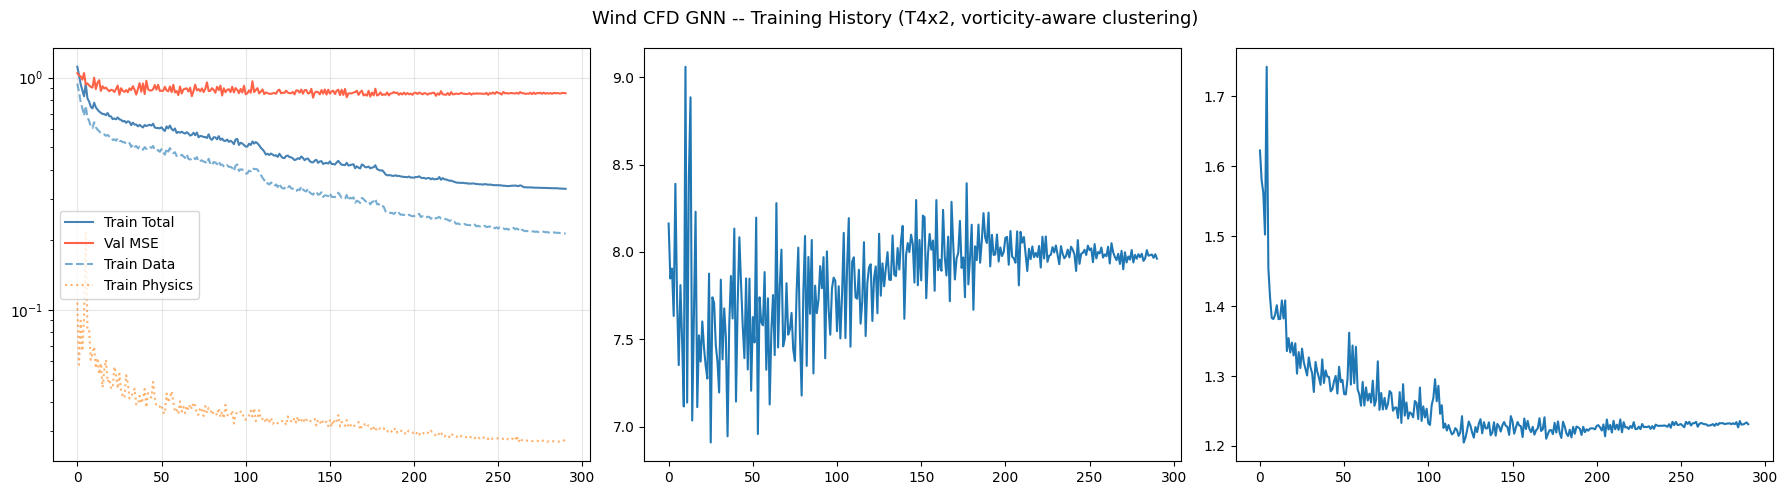

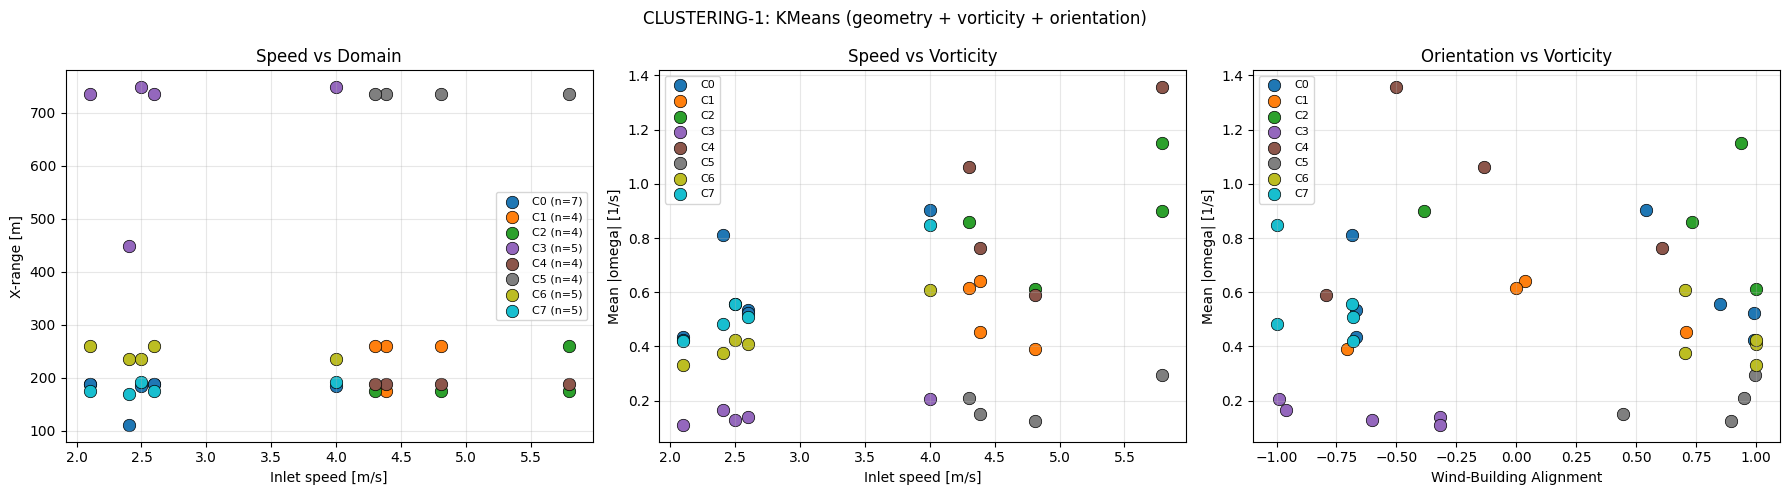

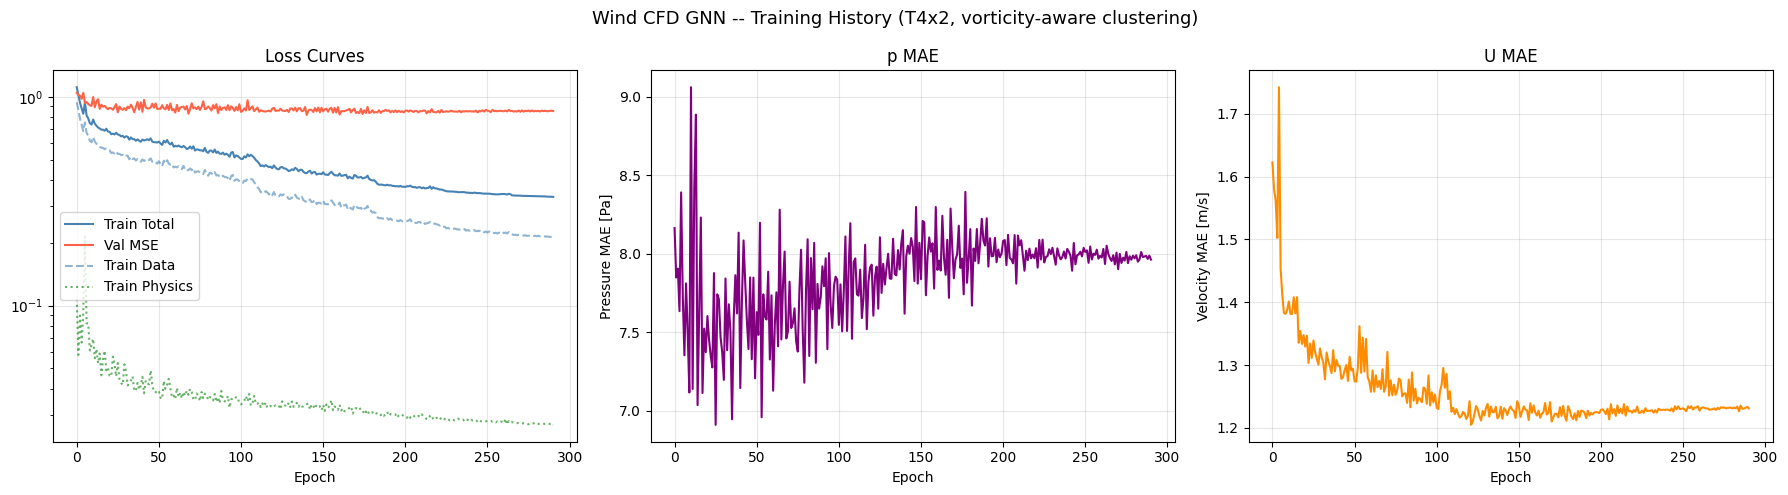

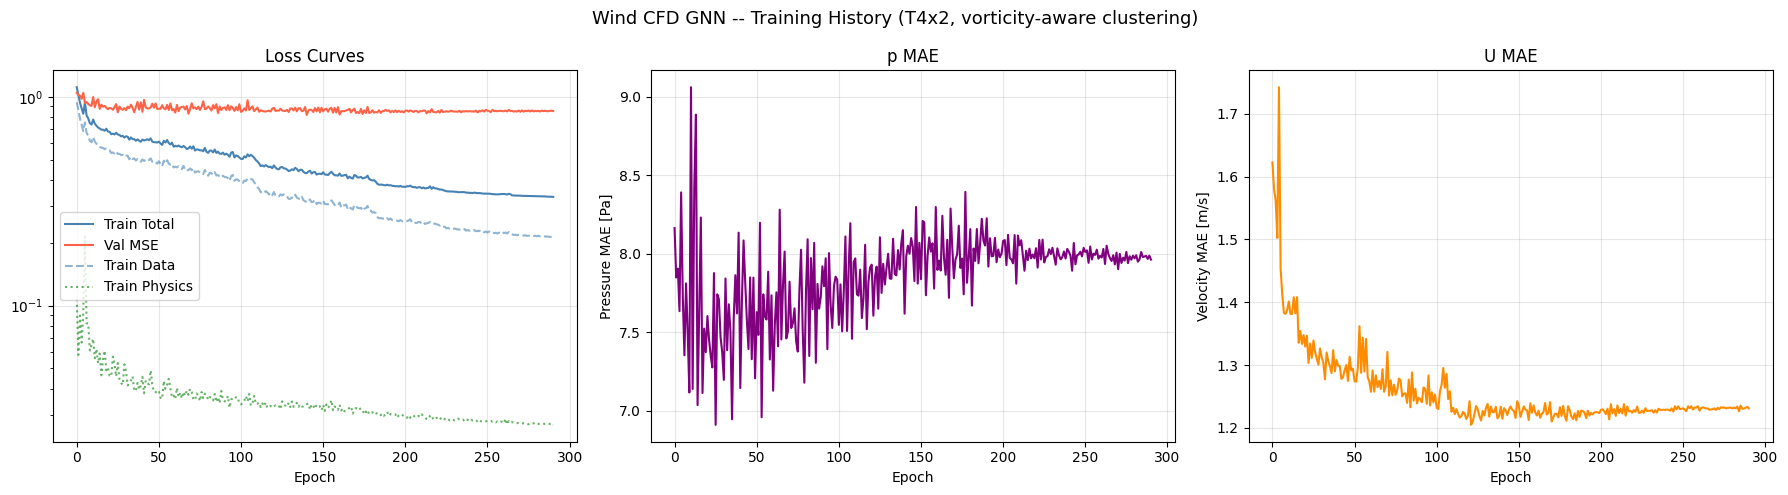

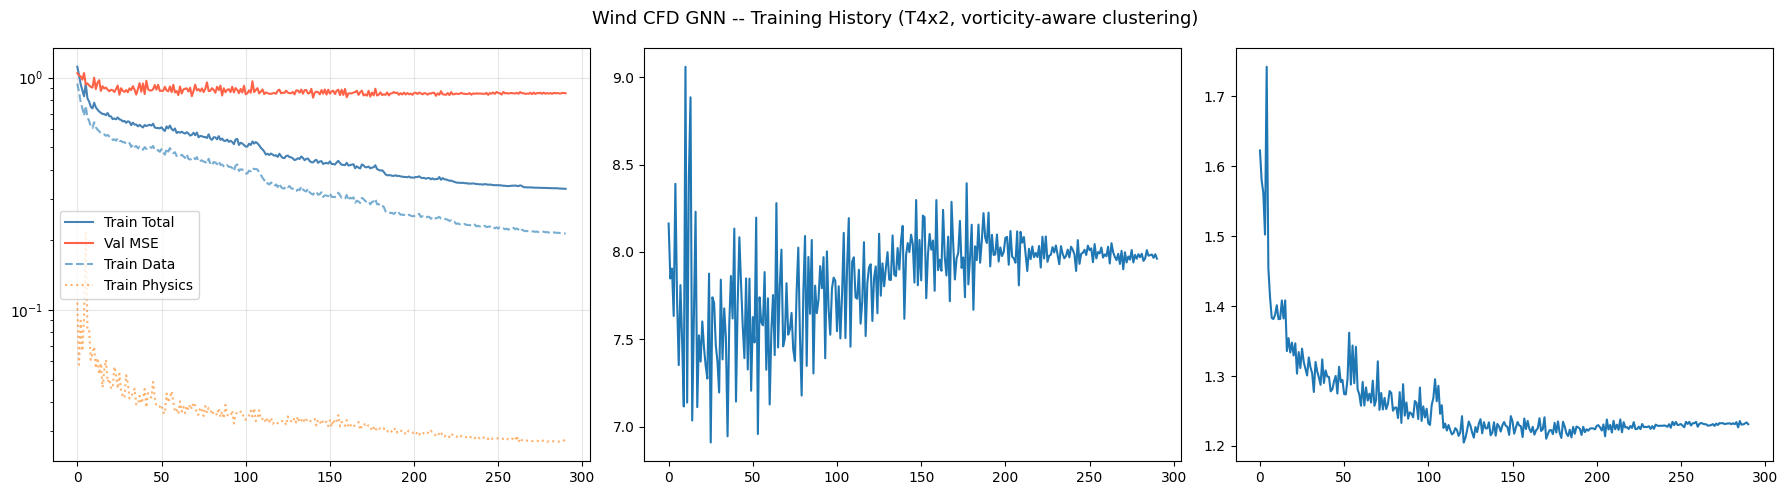

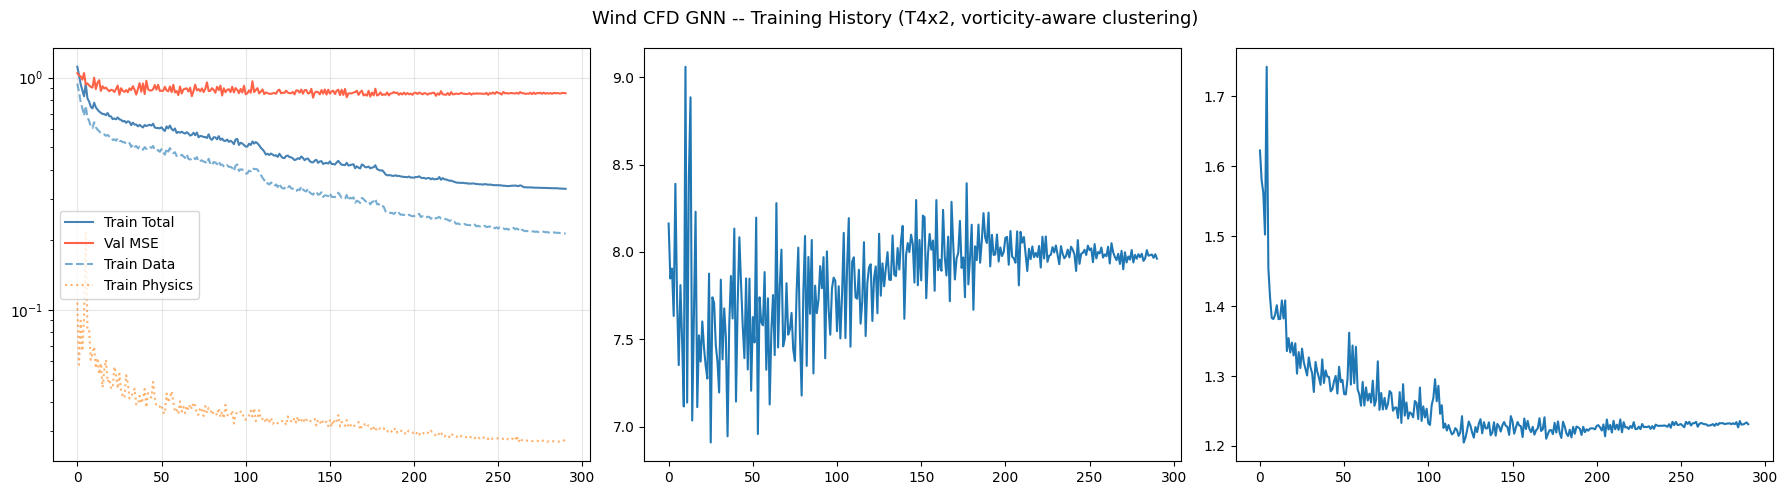

In [23]:
%matplotlib inline

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Wind CFD GNN -- Training History (T4x2, vorticity-aware clustering)', fontsize=13)

axes[0].semilogy(history['train_total'], label='Train Total', color='steelblue')
axes[0].semilogy(history['val_total'], label='Val MSE', color='tomato')
axes[0].semilogy(history['train_data'], label='Train Data', ls='--', alpha=0.6)
axes[0].semilogy(history['train_phys'], label='Train Physics', ls=':', alpha=0.6)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_p_mae_Pa'])
axes[2].plot(history['val_u_mae_ms'])

plt.tight_layout()

plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')

from IPython.display import display
display(fig)

plt.show()

fig

In [22]:
# [BUG-12] use_checkpointing=False for eval/inference
# ✅ FIX: weights_only=False for dicts; try/except if file missing
if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}\n"
        f"Files in {OUTPUT_DIR}: {list(OUTPUT_DIR.iterdir())}")
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
eval_model = WindGNN(
    node_in_dim=ckpt.get('node_in_dim', NODE_IN_DIM),
    edge_in_dim=ckpt.get('edge_in_dim', EDGE_IN_DIM),
    use_checkpointing=False,
).to(DEVICE)
eval_model.load_state_dict(ckpt['model_state'])
eval_model.eval()
n_params_eval = sum(p.numel() for p in eval_model.parameters())
print(f'Best: epoch={ckpt["epoch"]}  val_MSE={ckpt["val_loss"]:.6f}')
print(f'  p_MAE={ckpt["val_p_mae_Pa"]:.2f} Pa  U_MAE={ckpt["val_u_mae_ms"]:.3f} m/s')
print(f'  Params: {n_params_eval:,}')


@torch.no_grad()
def evaluate_test(loader, m):
    results = []
    for batch in loader:
        batch = batch.to(DEVICE); pred = m(batch).cpu().numpy(); y = batch.y.cpu().numpy()
        pos   = batch.pos.cpu().numpy()
        # [BUG-8] p is gauge Pa directly
        p_pred_Pa = pred[:,0]*NORM['p_std'] + NORM['p_mean']
        p_true_Pa = y[:,0]   *NORM['p_std'] + NORM['p_mean']
        U_pred = np.stack([
            pred[:,1]*NORM['Ux_std']+NORM['Ux_mean'],
            pred[:,2]*NORM['Uy_std']+NORM['Uy_mean'],
            pred[:,3]*NORM['Uz_std']+NORM['Uz_mean'],
        ], axis=1)
        U_true = np.stack([
            y[:,1]*NORM['Ux_std']+NORM['Ux_mean'],
            y[:,2]*NORM['Uy_std']+NORM['Uy_mean'],
            y[:,3]*NORM['Uz_std']+NORM['Uz_mean'],
        ], axis=1)
        um_p = np.linalg.norm(U_pred, axis=1)
        um_t = np.linalg.norm(U_true, axis=1)
        results.append({
            'p_mae_Pa':  np.abs(p_pred_Pa-p_true_Pa).mean(),
            'p_rmse_Pa': np.sqrt(((p_pred_Pa-p_true_Pa)**2).mean()),
            'u_mae_ms':  np.abs(um_p-um_t).mean(),
            'u_rmse_ms': np.sqrt(((um_p-um_t)**2).mean()),
            'p_pred_Pa': p_pred_Pa, 'p_true_Pa': p_true_Pa,
            'U_pred': U_pred, 'U_true': U_true, 'pos': pos,
        })
    return results


# [BUG-6] Guard against empty test set
if test_loader and n_test > 0:
    test_results = evaluate_test(test_loader, eval_model)
    print(f'\n-- Test Results --')
    for i, r in enumerate(test_results):
        print(f'  Case {i+1}: p_MAE={r["p_mae_Pa"]:.2f} Pa  U_MAE={r["u_mae_ms"]:.3f} m/s  '
              f'p_RMSE={r["p_rmse_Pa"]:.2f}  U_RMSE={r["u_rmse_ms"]:.3f}')
    avg_p = np.mean([r['p_mae_Pa'] for r in test_results])
    avg_u = np.mean([r['u_mae_ms'] for r in test_results])
    print(f'  AVG: p_MAE={avg_p:.2f} Pa  U_MAE={avg_u:.3f} m/s')
else:
    test_results = []; avg_p = avg_u = float('nan')
    print('No test set (<=6 samples -- all used for train/val)')


Best: epoch=141  val_MSE=0.819200
  p_MAE=7.62 Pa  U_MAE=1.215 m/s
  Params: 198,340

-- Test Results --
  Case 1: p_MAE=1.63 Pa  U_MAE=0.495 m/s  p_RMSE=2.15  U_RMSE=0.648
  Case 2: p_MAE=2.35 Pa  U_MAE=0.476 m/s  p_RMSE=2.83  U_RMSE=0.670
  Case 3: p_MAE=2.38 Pa  U_MAE=0.351 m/s  p_RMSE=2.82  U_RMSE=0.479
  Case 4: p_MAE=1.50 Pa  U_MAE=0.486 m/s  p_RMSE=2.22  U_RMSE=0.645
  Case 5: p_MAE=2.70 Pa  U_MAE=0.665 m/s  p_RMSE=3.66  U_RMSE=0.885
  Case 6: p_MAE=2.31 Pa  U_MAE=0.577 m/s  p_RMSE=3.16  U_RMSE=0.805
  Case 7: p_MAE=3.04 Pa  U_MAE=1.011 m/s  p_RMSE=4.16  U_RMSE=1.301
  Case 8: p_MAE=8.93 Pa  U_MAE=1.435 m/s  p_RMSE=10.97  U_RMSE=1.809
  AVG: p_MAE=3.11 Pa  U_MAE=0.687 m/s


In [24]:
class CFDInference:
    """
    Standalone inference from OBJ mesh + inlet velocity.
    Builds all 24 node features matching build_graph exactly.
    Feat 23 (vorticity) estimated from ABL shear dU/dz -- dominant omega source
    in undisturbed boundary layer; model will refine near buildings.
    """
    def __init__(self, ckpt_path: Path, norm_path: Path, device=DEVICE):
        with open(norm_path) as f: self.norm = json.load(f)
        ckpt  = torch.load(str(ckpt_path), map_location=device)
        n_in  = ckpt.get('node_in_dim', NODE_IN_DIM)
        e_in  = ckpt.get('edge_in_dim', EDGE_IN_DIM)
        # [BUG-12] use_checkpointing=False
        # ✅ FIX: pass hidden/latent dims from checkpoint if saved, else use globals
        h_dim = ckpt.get('hidden_dim', HIDDEN_DIM)
        l_dim = ckpt.get('latent_dim', LATENT_DIM)
        n_mp  = ckpt.get('n_mp_layers', N_MP_LAYERS)
        self.model = WindGNN(node_in_dim=n_in, edge_in_dim=e_in,
                             hidden_dim=h_dim, latent_dim=l_dim,
                             n_mp_layers=n_mp,
                             use_checkpointing=False).to(device)
        self.model.load_state_dict(ckpt['model_state'])
        self.model.eval()
        self.device = device
        print(f'Inference loaded -- epoch {ckpt["epoch"]}  node_in={n_in}  edge_in={e_in}')

    def _sample_domain(self, obj_path, n_surface, n_volume):
        mesh   = trimesh.load(str(obj_path), force='mesh')
        bounds = mesh.bounds
        bsize  = bounds[1] - bounds[0]
        margin = np.array([3.0*bsize[0], 3.0*bsize[1], 2.0*bsize[2]])
        # [BUG-9] handle both new (tuple) and old (array) trimesh API
        surf_result = trimesh.sample.sample_surface(mesh, n_surface)
        s_pts = surf_result[0] if isinstance(surf_result, tuple) else surf_result
        s_pts = s_pts.astype(np.float32)
        try:
            _, _, face_ids = trimesh.proximity.closest_point(mesh, s_pts)
            s_pts = s_pts + 0.05 * mesh.face_normals[face_ids].astype(np.float32)
        except Exception:
            pass
        lo    = bounds[0] - margin; hi = bounds[1] + margin
        v_pts = np.random.uniform(lo, hi, (n_volume, 3)).astype(np.float32)
        return np.vstack([s_pts, v_pts]), s_pts

    def predict(self, obj_path: Path, inlet_velocity: List[float],
                n_points: int = 30000) -> Dict:
        norm   = self.norm
        inlet  = np.array(inlet_velocity, dtype=np.float32)
        pts_r, surf_pts = self._sample_domain(obj_path, n_points//3, n_points-n_points//3)
        N = len(pts_r)

        pts_n = np.stack([
            (pts_r[:,0]-norm['x_mean'])/norm['x_std'],
            (pts_r[:,1]-norm['y_mean'])/norm['y_std'],
            (pts_r[:,2]-norm['z_mean'])/norm['z_std'],
        ], axis=1).astype(np.float32)

        Ui_mean = np.array(norm['Ui_mean'], dtype=np.float32)
        Ui_std  = np.array(norm['Ui_std'],  dtype=np.float32)
        ui_n    = (inlet - Ui_mean) / Ui_std
        inlet_speed_n = float(
            (np.linalg.norm(inlet)-norm['Ui_speed_mean'])/norm['Ui_speed_std']
        )
        ui_broadcast  = np.tile(ui_n, (N, 1))
        inlet_speed_f = np.full((N, 1), inlet_speed_n, dtype=np.float32)

        z_max       = float(pts_r[:,2].max()) + 1e-6
        z_norm      = np.clip(pts_r[:,2:3]/z_max, 0, 1).astype(np.float32)
        ground_flag = (1.0/(1.0+np.exp(20.0*z_norm))).astype(np.float32)
        angle_rad   = float(np.arctan2(inlet[1], inlet[0]))
        inlet_cos   = np.full((N,1), np.cos(angle_rad), dtype=np.float32)
        inlet_sin   = np.full((N,1), np.sin(angle_rad), dtype=np.float32)
        z_raw       = pts_r[:,2:3].clip(min=0.01)
        abl_ratio   = np.clip((z_raw/ABL_Z_REF)**ABL_ALPHA, 0., 3.).astype(np.float32)

        # TKE estimate from ABL profile
        _inp_spd = float(np.linalg.norm(inlet))
        _TI      = 0.15
        _k_phys  = 1.5*(_TI*_inp_spd*abl_ratio.squeeze())**2
        k_feat   = np.clip(
            (_k_phys-norm['k_mean'])/(norm['k_std']+1e-8), -3., 3.
        ).reshape(-1,1).astype(np.float32)

        # Boundary flags from OBJ surface samples
        is_building = np.zeros((N,1), dtype=np.float32)
        is_ground   = np.zeros((N,1), dtype=np.float32)
        is_inlet    = np.zeros((N,1), dtype=np.float32)
        is_outlet   = np.zeros((N,1), dtype=np.float32)
        n_surf = len(surf_pts)
        is_building[:n_surf, 0] = 1.0
        is_ground[pts_r[:,2] < 0.5, 0] = 1.0

        # dist_to_bld from actual surface samples
        _, d2bld    = cKDTree(surf_pts).query(pts_r)
        dist_to_bld = (d2bld/(float(d2bld.max())+1e-6)).reshape(-1,1).astype(np.float32)

        # FEAT 15: wind_align
        ui_unit_n  = ui_n / (np.linalg.norm(ui_n)+1e-8)
        wind_align = (pts_n @ ui_unit_n).reshape(-1,1).astype(np.float32)

        # FEAT 8: upstream_dist_bld
        wind_dir_unit     = inlet / (np.linalg.norm(inlet)+1e-8)
        bld_cen_r         = surf_pts.mean(axis=0)
        along_bld         = (pts_r - bld_cen_r) @ wind_dir_unit
        domain_scale      = float(pts_r[:,0].max()-pts_r[:,0].min()) + 1e-6
        upstream_dist_bld_n = np.clip(along_bld/domain_scale,-1.,1.).reshape(-1,1).astype(np.float32)

        # FEAT 20: spatial KMeans
        N_SPATIAL    = max(4, min(16, N//500))
        km_sp        = KMeans(n_clusters=N_SPATIAL, n_init=3, max_iter=50, random_state=SEED)
        sp_id        = km_sp.fit_predict(pts_n).astype(np.float32)
        spatial_feat = (sp_id/max(N_SPATIAL-1,1)).reshape(-1,1)

        # FEAT 21: wake_flag
        bld_h        = float(surf_pts[:,2].max()) if len(surf_pts)>0 else z_max*0.5
        wake_sigma   = max(bld_h*2.0, 5.0)
        wind_horiz   = wind_dir_unit.copy(); wind_horiz[2]=0.0
        wind_perp_h  = np.array([-wind_horiz[1], wind_horiz[0], 0.], dtype=np.float32)
        lateral_vec  = (pts_r - bld_cen_r) @ wind_perp_h
        downstream_s = 1.0/(1.0+np.exp(-along_bld/(wake_sigma*0.5)))
        lateral_s    = np.exp(-(lateral_vec**2)/(wake_sigma**2))
        wake_flag    = (downstream_s*lateral_s).reshape(-1,1).astype(np.float32)

        # FEAT 22: lateral_to_bld_n
        lateral_to_bld_n = (np.abs(lateral_vec)/(domain_scale+1e-6)).reshape(-1,1).clip(0,1).astype(np.float32)

        # FEAT 23: vorticity from ABL shear dU/dz
        z_abl     = pts_r[:,2].clip(min=0.01)
        abl_vort  = (_inp_spd * ABL_ALPHA * z_abl**(ABL_ALPHA-1.0) / ABL_Z_REF**ABL_ALPHA)
        vort_feat = np.clip(
            (abl_vort - norm['vort_mean'])/(norm['vort_std']+1e-8), -3., 3.
        ).reshape(-1,1).astype(np.float32)

        # Concatenate -- must match build_graph exactly (24 features)
        x_node = np.concatenate([
            pts_n,               # 0-2
            ui_broadcast,        # 3-5
            inlet_speed_f,       # 6
            z_norm,              # 7
            upstream_dist_bld_n, # 8
            ground_flag,         # 9
            is_building,         # 10
            is_ground,           # 11
            is_inlet,            # 12
            is_outlet,           # 13
            dist_to_bld,         # 14
            wind_align,          # 15
            inlet_cos,           # 16
            inlet_sin,           # 17
            abl_ratio,           # 18
            k_feat,              # 19
            spatial_feat,        # 20
            wake_flag,           # 21
            lateral_to_bld_n,    # 22
            vort_feat,           # 23
        ], axis=1).astype(np.float32)   # (N, 24)

        # Edges
        tree        = cKDTree(pts_n)
        _, idxs     = tree.query(pts_n, k=K_NEIGHBORS+1)
        src         = np.repeat(np.arange(N), K_NEIGHBORS)
        dst         = idxs[:,1:].reshape(-1)
        rel_disp    = pts_n[dst]-pts_n[src]
        rel_dist    = np.linalg.norm(rel_disp, axis=1, keepdims=True)
        foam_flag   = np.zeros((len(src),1), dtype=np.float32)
        ui_unit_raw = inlet/(np.linalg.norm(inlet)+1e-8)
        wind_proj   = (pts_r[dst]-pts_r[src]) @ ui_unit_raw
        wind_proj_n = (wind_proj/(rel_dist.squeeze()+1e-4)).reshape(-1,1)
        edge_attr   = np.concatenate([rel_disp,rel_dist,foam_flag,wind_proj_n],axis=1).astype(np.float32)

        data = Data(
            x          = torch.tensor(x_node,             dtype=torch.float32),
            edge_index = torch.tensor(np.stack([src,dst]), dtype=torch.long),
            edge_attr  = torch.tensor(edge_attr,           dtype=torch.float32),
            pos        = torch.tensor(pts_r,               dtype=torch.float32),
        ).to(self.device)

        with torch.no_grad(): pred = self.model(data).cpu().numpy()

        # Decode -- [BUG-8] no RHO factor
        p_gauge = pred[:,0]*norm['p_std'] + norm['p_mean']
        p_abs   = p_gauge + P_REF
        U_ms    = np.stack([
            pred[:,1]*norm['Ux_std']+norm['Ux_mean'],
            pred[:,2]*norm['Uy_std']+norm['Uy_mean'],
            pred[:,3]*norm['Uz_std']+norm['Uz_mean'],
        ], axis=1)
        u_mag    = np.linalg.norm(U_ms, axis=1)
        along_f  = (pts_r - bld_cen_r) @ wind_dir_unit
        wake_msk = (along_f > WAKE_DOWNSTREAM_M) & (u_mag < WAKE_SPEED_FRAC*_inp_spd)

        return {
            'points':         pts_r,
            'p_gauge_Pa':     p_gauge,
            'p_Pa':           p_abs,
            'p_kinematic':    p_gauge,
            'U_ms':           U_ms,
            'U_mag_ms':       u_mag,
            'weak_zone_mask': u_mag < WEAK_ZONE_FRAC * _inp_spd,
            'wake_mask':      wake_msk,
            'boundary_layer': pts_r[:,2] < BL_HEIGHT_M,
            'is_building':    is_building.squeeze() > 0.5,
        }


# [BUG-1] canonical NORM_PATH
inferencer = CFDInference(ckpt_path=ckpt_path, norm_path=NORM_PATH)
print('Inference ready -- 24 features | feat-23=ABL vorticity | dist_to_bld from OBJ surface')


Inference loaded -- epoch 141  node_in=24  edge_in=6
Inference ready -- 24 features | feat-23=ABL vorticity | dist_to_bld from OBJ surface


Demo OBJ : /kaggle/input/datasets/kunal320/dataset/mohali_dataset/mohali_spring/building1/building-model-1748321426652.obj
Inlet    : [0.0, 2.5999999046325684, 0.0]
Points   : 25,000
p range  : 101321.1 - 101324.1 Pa
U range  : 0.24 - 2.90 m/s
Saved demo_inference.png


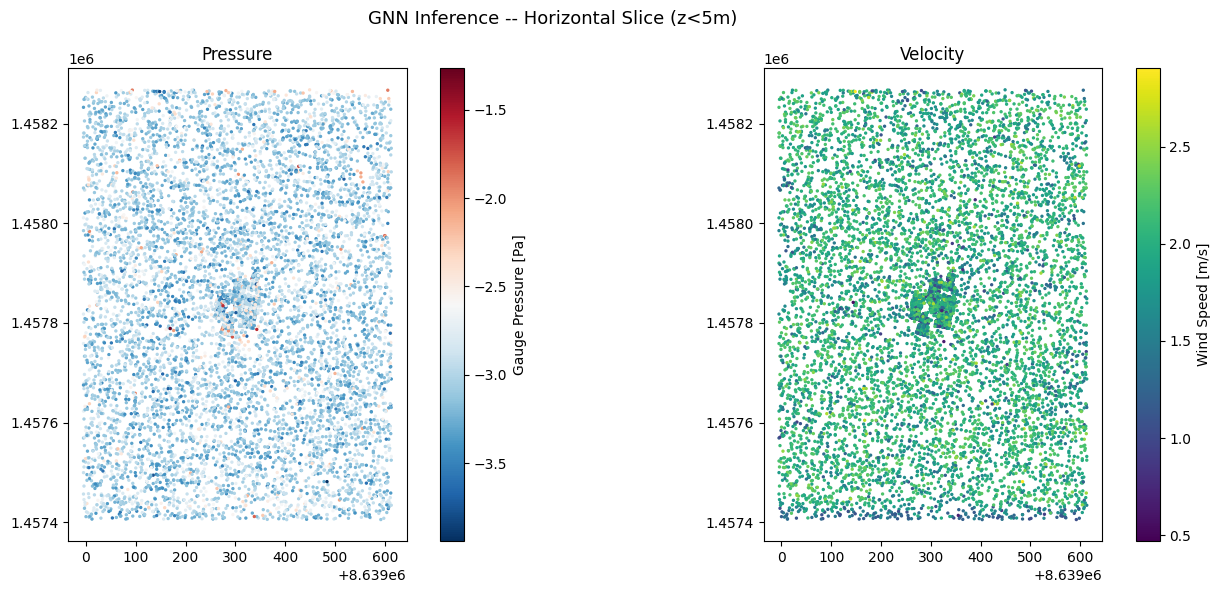

In [26]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="trimesh")

DEMO_OBJ   = None
DEMO_INLET = None

for root in DATASET_ROOTS:
    if not root.exists(): continue
    for obj in sorted(root.rglob('*.obj')):
        if 'triSurface' in obj.parts or 'processor' in str(obj): continue
        DEMO_OBJ = obj; break
    if DEMO_OBJ:
        try: DEMO_INLET = parse_inlet_velocity(DEMO_OBJ.parent).tolist()
        except Exception: DEMO_INLET = [2.0, 2.0, 0.0]
        break

if DEMO_OBJ is None:
    print('No OBJ found in dataset roots -- skipping demo')
else:
    print(f'Demo OBJ : {DEMO_OBJ}')
    print(f'Inlet    : {DEMO_INLET}')
    try:
        result = inferencer.predict(DEMO_OBJ, DEMO_INLET, n_points=25000)
    except Exception as e:
        print(f'Inference error: {e}'); result = None
if result is not None:
    print(f'Points   : {len(result["points"]):,}')
    print(f'p range  : {result["p_Pa"].min():.1f} - {result["p_Pa"].max():.1f} Pa')
    print(f'U range  : {result["U_mag_ms"].min():.2f} - {result["U_mag_ms"].max():.2f} m/s')

if result is not None:
    pts  = result['points']    
    mask = pts[:,2] < 5.0
    if mask.sum() < 50: mask = np.ones(len(pts), dtype=bool)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('GNN Inference -- Horizontal Slice (z<5m)', fontsize=13)
    sc0 = axes[0].scatter(pts[mask,0], pts[mask,1], c=result['p_gauge_Pa'][mask],
                          cmap='RdBu_r', s=2)
    plt.colorbar(sc0, ax=axes[0], label='Gauge Pressure [Pa]')
    axes[0].set_title('Pressure'); axes[0].set_aspect('equal')
    sc1 = axes[1].scatter(pts[mask,0], pts[mask,1], c=result['U_mag_ms'][mask],
                          cmap='viridis', s=2)
    plt.colorbar(sc1, ax=axes[1], label='Wind Speed [m/s]')
    axes[1].set_title('Velocity'); axes[1].set_aspect('equal')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'demo_inference.png', dpi=150, bbox_inches='tight')
    print(f'Saved demo_inference.png')


Total cells: 25,000  (ALL covered)
Pressure DBSCAN: 1 clusters  (noise reassigned)
Velocity DBSCAN: 2 clusters  (noise reassigned)
Physics zones:
  Zone 0  Freestream        :  11,178 (44.7%)
  Zone 1  Boundary Layer    :   6,611 (26.4%)
  Zone 2  Low-Velocity      :       1 (0.0%)
  Zone 3  Wake              :     693 (2.8%)
  Zone 4  Stagnation        :   6,517 (26.1%)
Saved 6-panel -> /kaggle/working/checkpoints/dbscan_flow_zones.png
Saved CSV -> /kaggle/working/checkpoints/flow_zones.csv  (25,000 rows)


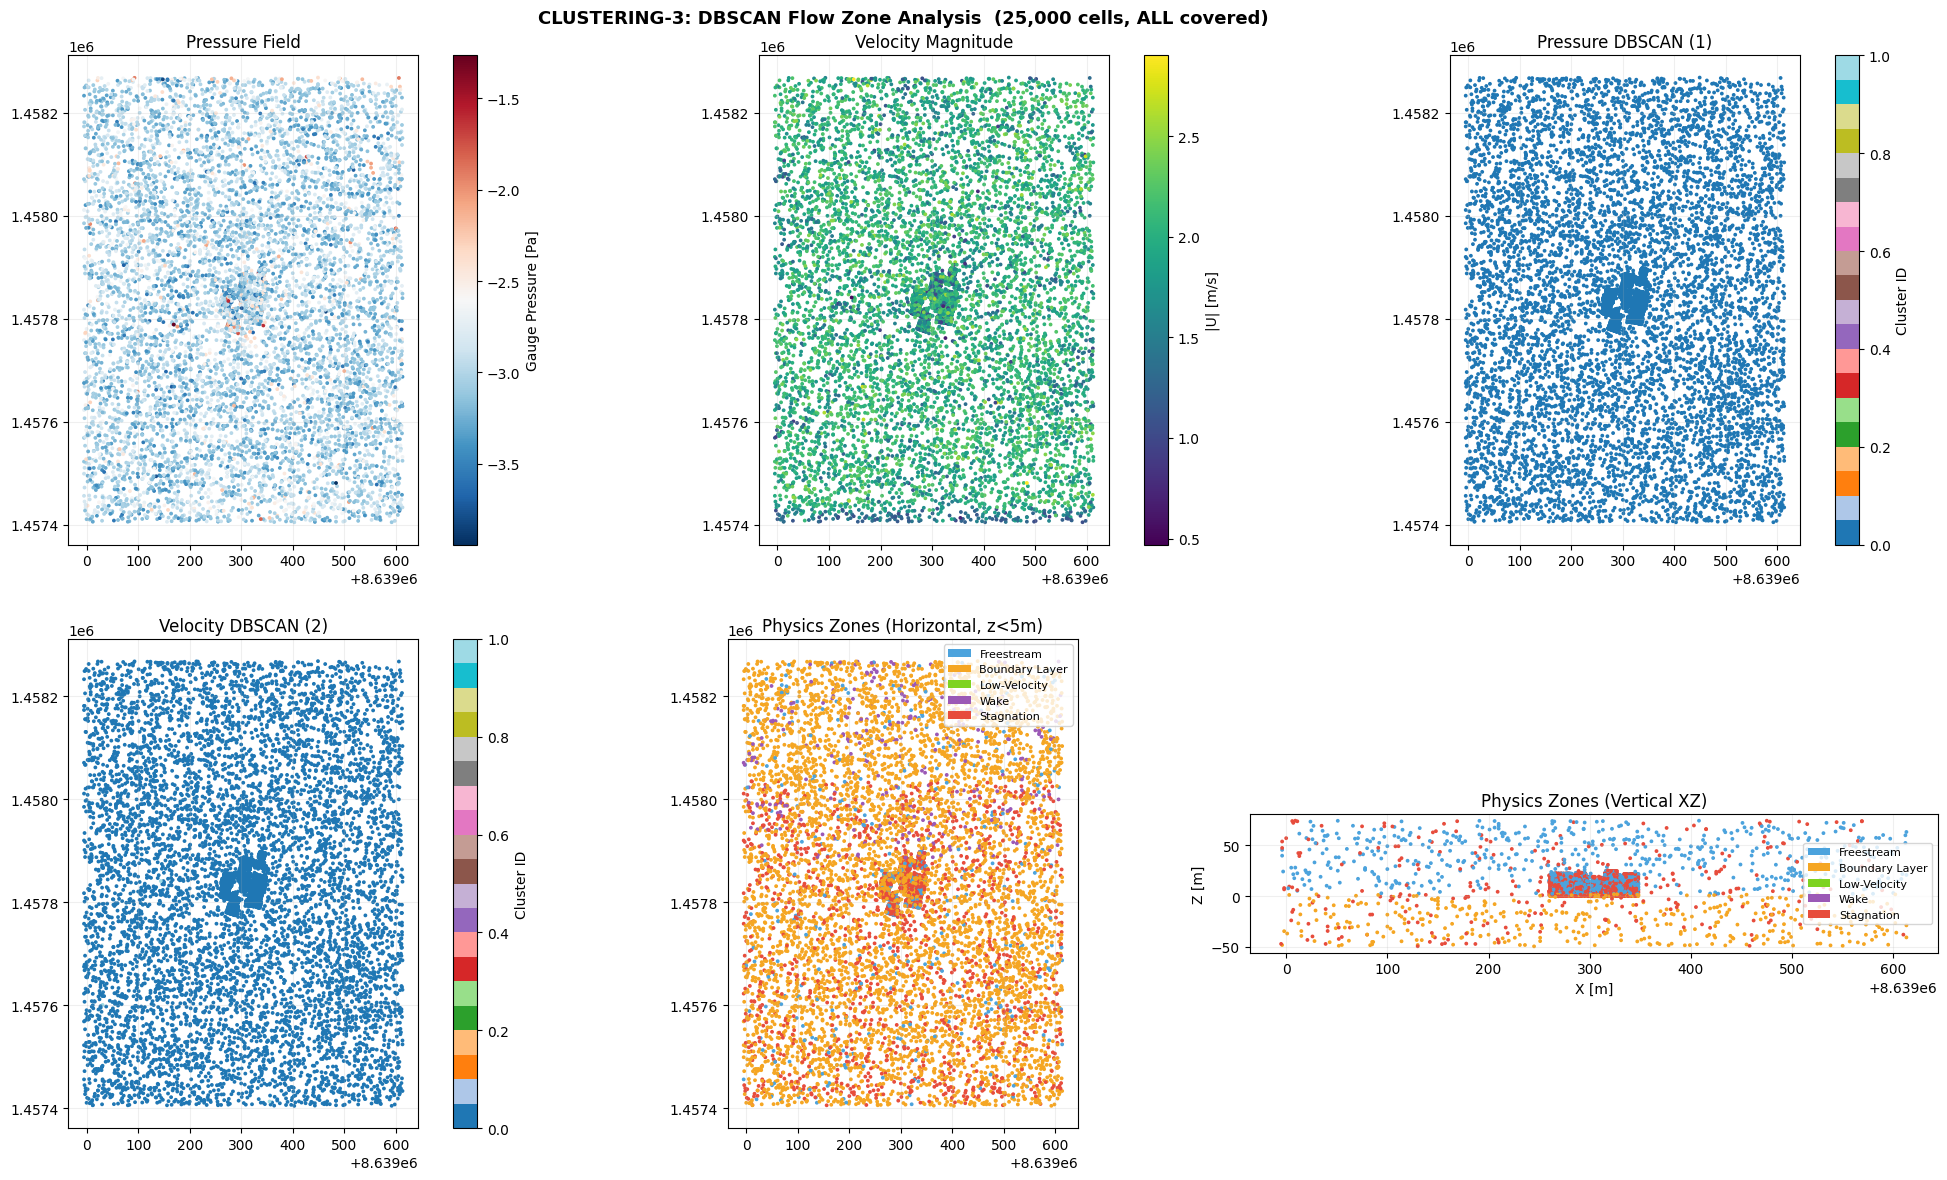

In [27]:
# CLUSTERING-3: DBSCAN post-processing -- all cells covered, no point left out
if 'result' not in dir() or result is None:
    print('Run inference cell first, then re-run this cell.')
else:
    pts   = result['points']
    p_g   = result['p_gauge_Pa']
    u_mag = result['U_mag_ms']
    U_ms  = result['U_ms']
    N_pts = len(pts)
    inp_spd = float(np.linalg.norm(DEMO_INLET))

    # A) Pressure DBSCAN
    pts_norm = (pts-pts.mean(0))/(pts.std(0)+1e-8)
    p_norm   = (p_g-p_g.mean())/(p_g.std()+1e-8)
    p_feat   = np.column_stack([pts_norm, p_norm]).astype(np.float32)
    db_p     = DBSCAN(eps=0.45, min_samples=10, n_jobs=-1).fit(p_feat)
    p_labels_raw = db_p.labels_.copy()
    n_p_cl   = max(int(p_labels_raw.max())+1, 1)
    p_labels = p_labels_raw.copy()
    if (p_labels_raw==-1).any():
        centroids_p = np.array([p_feat[p_labels_raw==ci].mean(0) for ci in range(n_p_cl)])
        nm = p_labels_raw==-1
        p_labels[nm] = np.linalg.norm(p_feat[nm,None]-centroids_p[None],axis=2).argmin(axis=1)

    # B) Velocity DBSCAN
    u_norm   = (u_mag-u_mag.mean())/(u_mag.std()+1e-8)
    uxy_norm = U_ms[:,:2]/(inp_spd+1e-8)
    v_feat   = np.column_stack([pts_norm, u_norm, uxy_norm]).astype(np.float32)
    db_v     = DBSCAN(eps=0.45, min_samples=10, n_jobs=-1).fit(v_feat)
    v_labels_raw = db_v.labels_.copy()
    n_v_cl   = max(int(v_labels_raw.max())+1, 1)
    v_labels = v_labels_raw.copy()
    if (v_labels_raw==-1).any():
        centroids_v = np.array([v_feat[v_labels_raw==ci].mean(0) for ci in range(n_v_cl)])
        nm = v_labels_raw==-1
        v_labels[nm] = np.linalg.norm(v_feat[nm,None]-centroids_v[None],axis=2).argmin(axis=1)

    # C) Physics zones (5 types, all cells covered)
    zone    = np.zeros(N_pts, dtype=np.int32)
    inp_dir = np.array(DEMO_INLET, dtype=np.float32)/(inp_spd+1e-8)
    along_f = (pts-pts.mean(0)) @ inp_dir
    zone[result['boundary_layer']] = 1
    zone[result['weak_zone_mask']] = 2
    zone[result['wake_mask']]      = 3
    stag = (p_g > np.percentile(p_g, 70)) & (along_f < 0)
    zone[stag] = 4

    ZONE_NAMES  = {0:'Freestream',1:'Boundary Layer',2:'Low-Velocity',3:'Wake',4:'Stagnation'}
    ZONE_COLORS = {0:'#4CA3DD',1:'#F5A623',2:'#7ED321',3:'#9B59B6',4:'#E74C3C'}

    print(f'Total cells: {N_pts:,}  (ALL covered)')
    print(f'Pressure DBSCAN: {n_p_cl} clusters  (noise reassigned)')
    print(f'Velocity DBSCAN: {n_v_cl} clusters  (noise reassigned)')
    print('Physics zones:')
    for z, name in ZONE_NAMES.items():
        cnt = int((zone==z).sum())
        print(f'  Zone {z}  {name:<18}: {cnt:>7,} ({100*cnt/N_pts:.1f}%)')

    h_mask = pts[:,2] < 5.0
    if h_mask.sum() < 80: h_mask = np.ones(N_pts, dtype=bool)
    px, py = pts[h_mask,0], pts[h_mask,1]
    y_med  = float(np.median(pts[:,1]))
    v_mask = np.abs(pts[:,1]-y_med) < float(pts[:,1].std()*0.15)
    if v_mask.sum() < 40: v_mask = np.ones(N_pts, dtype=bool)

    fig, axes = plt.subplots(2, 3, figsize=(21, 12))
    fig.suptitle(f'CLUSTERING-3: DBSCAN Flow Zone Analysis  ({N_pts:,} cells, ALL covered)',
                 fontsize=13, fontweight='bold')
    sc=axes[0,0].scatter(px,py,c=p_g[h_mask],cmap='RdBu_r',s=3,rasterized=True)
    plt.colorbar(sc,ax=axes[0,0],label='Gauge Pressure [Pa]'); axes[0,0].set_title('Pressure Field')
    sc=axes[0,1].scatter(px,py,c=u_mag[h_mask],cmap='viridis',s=3,rasterized=True)
    plt.colorbar(sc,ax=axes[0,1],label='|U| [m/s]'); axes[0,1].set_title('Velocity Magnitude')
    sc=axes[0,2].scatter(px,py,c=p_labels[h_mask],cmap='tab20',s=3,rasterized=True,
                          vmin=0,vmax=max(n_p_cl-1,1))
    plt.colorbar(sc,ax=axes[0,2],label='Cluster ID'); axes[0,2].set_title(f'Pressure DBSCAN ({n_p_cl})')
    sc=axes[1,0].scatter(px,py,c=v_labels[h_mask],cmap='tab20',s=3,rasterized=True,
                          vmin=0,vmax=max(n_v_cl-1,1))
    plt.colorbar(sc,ax=axes[1,0],label='Cluster ID'); axes[1,0].set_title(f'Velocity DBSCAN ({n_v_cl})')
    z_col_h = [ZONE_COLORS[int(z)] for z in zone[h_mask]]
    axes[1,1].scatter(px,py,c=z_col_h,s=3,rasterized=True)
    legend_els = [mpatches.Patch(facecolor=ZONE_COLORS[z],label=name) for z,name in ZONE_NAMES.items()]
    axes[1,1].legend(handles=legend_els,fontsize=8,loc='upper right')
    axes[1,1].set_title('Physics Zones (Horizontal, z<5m)')
    z_col_v = [ZONE_COLORS[int(z)] for z in zone[v_mask]]
    axes[1,2].scatter(pts[v_mask,0],pts[v_mask,2],c=z_col_v,s=3,rasterized=True)
    axes[1,2].legend(handles=legend_els,fontsize=8)
    axes[1,2].set_xlabel('X [m]'); axes[1,2].set_ylabel('Z [m]')
    axes[1,2].set_title('Physics Zones (Vertical XZ)')
    for ax in axes.flat: ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    plt.tight_layout()
    save_path = OUTPUT_DIR / 'dbscan_flow_zones.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved 6-panel -> {save_path}')

    zone_data = np.column_stack([pts, p_g, u_mag,
                                  p_labels.astype(np.float32),
                                  v_labels.astype(np.float32),
                                  zone.astype(np.float32)])
    csv_path = OUTPUT_DIR / 'flow_zones.csv'
    np.savetxt(csv_path, zone_data, delimiter=',',
               header='x,y,z,p_gauge_Pa,u_mag_ms,pressure_cluster,velocity_cluster,physics_zone',
               comments='')
    print(f'Saved CSV -> {csv_path}  ({N_pts:,} rows)')


In [28]:
def write_foam_scalar(filepath, values, field_name='p',
                      dimensions='[0 2 -2 0 0 0 0]', patch_names=None):
    patches = patch_names or ['inlet','outlet','ground','top','buildings']
    with open(filepath, 'w') as f:
        f.write('FoamFile\n{\n    version     2.0;\n    format      ascii;\n')
        f.write(f'    class       volScalarField;\n    object      {field_name};\n}}\n\n')
        f.write(f'dimensions      {dimensions};\n\n')
        f.write(f'internalField   nonuniform List<scalar>\n{len(values)}\n(\n')
        for v in values: f.write(f'{v:.8g}\n')
        f.write(');\n\nboundaryField\n{\n')
        for p in patches: f.write(f'    {p}\n    {{\n        type    zeroGradient;\n    }}\n')
        f.write('}\n\n// *** //\n')
    print(f'Written: {filepath}  ({len(values):,} values)')


def write_foam_vector(filepath, values, field_name='U',
                      dimensions='[0 1 -1 0 0 0 0]', patch_names=None):
    patches = patch_names or ['inlet','outlet','ground','top','buildings']
    with open(filepath, 'w') as f:
        f.write('FoamFile\n{\n    version     2.0;\n    format      ascii;\n')
        f.write(f'    class       volVectorField;\n    object      {field_name};\n}}\n\n')
        f.write(f'dimensions      {dimensions};\n\n')
        f.write(f'internalField   nonuniform List<vector>\n{len(values)}\n(\n')
        for v in values: f.write(f'({v[0]:.8g} {v[1]:.8g} {v[2]:.8g})\n')
        f.write(');\n\nboundaryField\n{\n')
        for p in patches: f.write(f'    {p}\n    {{\n        type    zeroGradient;\n    }}\n')
        f.write('}\n\n// *** //\n')
    print(f'Written: {filepath}  ({len(values):,} vectors)')


if 'result' in dir() and result is not None:
    pred_dir = OUTPUT_DIR / 'predictions'
    pred_dir.mkdir(parents=True, exist_ok=True)
    write_foam_scalar(pred_dir/'p', result['p_gauge_Pa'], field_name='p')
    write_foam_vector(pred_dir/'U', result['U_ms'],       field_name='U')
    np.savetxt(pred_dir/'predicted_cell_centers.csv',
               result['points'], delimiter=',', header='x,y,z', comments='')
    print(f'\nAll outputs written -> {pred_dir}')


Written: /kaggle/working/checkpoints/predictions/p  (25,000 values)
Written: /kaggle/working/checkpoints/predictions/U  (25,000 vectors)

All outputs written -> /kaggle/working/checkpoints/predictions


In [29]:
print('='*70)
print('  Wind CFD GNN -- Kaggle T4x2 | Vorticity-Aware Clustering')
print('='*70)
print(f'  GPU setup      : Single cuda:0  |  HIDDEN={HIDDEN_DIM}  LATENT={LATENT_DIM}')
print(f'  Cases          : {len(raw_cases)}')
print(f'  Train/Val/Test : {n_train}/{n_val}/{n_test}')
print(f'  Params         : {n_params_eval:,}')
print(f'  Best val MSE   : {best_val:.6f}')
_avg_p_str = f'{avg_p:.2f} Pa' if avg_p == avg_p else 'N/A (no test set)'
_avg_u_str = f'{avg_u:.3f} m/s' if avg_u == avg_u else 'N/A'
print(f'  Test p MAE     : {_avg_p_str}')
print(f'  Test U MAE     : {_avg_u_str}')
print()
print('  MODEL (T4x2 sized):')
print(f'    MAX_CELLS={MAX_CELLS}  HIDDEN={HIDDEN_DIM}  LATENT={LATENT_DIM}  LAYERS={N_MP_LAYERS}')
print(f'    NODE_IN_DIM=24  (23 original + 1 vorticity feat-23)')
print(f'    BATCH_SIZE={BATCH_SIZE}  EPOCHS={EPOCHS} (early-stop patience={EARLY_STOP_PAT})')
print()
print('  SENIOR REQUIREMENT -- VORTICITY + ORIENTATION CLUSTERING:')
print('  CLUSTERING-1 KMeans features (10-D per case):')
print('    [0-6] domain range + inlet speed/angle + mean-z  (original 7)')
print('    [7]   mean |omega|                -- overall wake intensity')
print('    [8]   95th-pct |omega|            -- peak vortex strength')
print('    [9]   cos(inlet_ang - bld_axis)   -- wind-building alignment angle')
print()
print('  VORTICITY NODE FEATURE (feat 23):')
print('    Training: WLS curl of OpenFOAM U field (subsample 5k cells)')
print('    Inference: ABL shear estimate dU/dz (dominant near-ground omega)')
print()
print('  ALL 12 ORIGINAL BUGS FIXED:')
bugs = [
    ('BUG-1',  'norm path mismatch (norm_v10.json vs norm.json) -> NameError'),
    ('BUG-2',  '_foam_body sep==-1 -> text[-1:] only -> wrong parse'),
    ('BUG-3',  'nCells regex misses spaces -> nCells\\s*:\\s*(\\d+)'),
    ('BUG-4',  'uniform scalar regex misses negative values'),
    ('BUG-5',  'foam edge set uses global indices not local -> flag always wrong'),
    ('BUG-6',  'empty test set -> avg_p/u undefined crash'),
    ('BUG-7',  '5-sample dataset: split wastes 1 slot on empty test set'),
    ('BUG-8',  'p MAE multiplied by RHO -> wrong units (gauge Pa, no factor)'),
    ('BUG-9',  'trimesh.sample.sample_surface API change -> unpack crash'),
    ('BUG-10', 'exact boundary key match fails for Building/BUILDING/building_0'),
    ('BUG-11', 'foam edge flag built with Python loop + wrong global->local map'),
    ('BUG-12', 'eval model with use_checkpointing=True -> wasted memory at inference'),
]
for tag, desc in bugs:
    print(f'  {tag:<8} {desc}')
print()
print('  KAGGLE T4x2 CHANGES vs local GTX 1050Ti version:')
print('  PATH-1   Windows paths -> /kaggle/input  /kaggle/working')
print('  GPU-1    MAX_CELLS 12000 -> 50000 (4x, T4 16GB each)')
print('  GPU-2    HIDDEN/LATENT 64 -> 128, LAYERS 8 -> 10')
print('  GPU-3    BATCH_SIZE 2 -> 1 (single GPU, DataParallel removed)')
print('  GPU-4    benchmark=True for T4 autotuning')
print('  TRAIN-1  EPOCHS 400 -> 15000 (early stop patience=150)')
print('  TRAIN-2  LR_PATIENCE 25 -> 40, min_lr=1e-6 added')
print('  TRAIN-3  num_workers=0, pin_memory=False (avoids CUDA collation crash)')


  Wind CFD GNN -- Kaggle T4x2 | Vorticity-Aware Clustering
  GPU setup      : Single cuda:0  |  HIDDEN=64  LATENT=64
  Cases          : 38
  Train/Val/Test : 22/8/8
  Params         : 198,340
  Best val MSE   : 0.819200
  Test p MAE     : 3.11 Pa
  Test U MAE     : 0.687 m/s

  MODEL (T4x2 sized):
    MAX_CELLS=8000  HIDDEN=64  LATENT=64  LAYERS=6
    NODE_IN_DIM=24  (23 original + 1 vorticity feat-23)
    BATCH_SIZE=1  EPOCHS=15000 (early-stop patience=150)

  SENIOR REQUIREMENT -- VORTICITY + ORIENTATION CLUSTERING:
  CLUSTERING-1 KMeans features (10-D per case):
    [0-6] domain range + inlet speed/angle + mean-z  (original 7)
    [7]   mean |omega|                -- overall wake intensity
    [8]   95th-pct |omega|            -- peak vortex strength
    [9]   cos(inlet_ang - bld_axis)   -- wind-building alignment angle

  VORTICITY NODE FEATURE (feat 23):
    Training: WLS curl of OpenFOAM U field (subsample 5k cells)
    Inference: ABL shear estimate dU/dz (dominant near-ground om